# 114-2 社群媒體分析 2nd 讀書會：PPT ETF 輿情分析



組別：Group 1  
組員：  
```
J144020003 李國輝 、M144020007 詹襄秝 、M144020020 林芷庭 、M144020021 劉淨涵 、M144020030 賴昱霖  
M134020047 廖經恆 、M144020052 張恩誠 、M144020056 張祐豪 、M144020068 陳啓恩  
```
動機：在**台灣 ETF 市場規模激增**的背景下，透過模型**分析 PTT 鄉民的討論熱度與情緒趨勢**，從中提取出投資者最關心的**核心主題**，並驗證**社群聲量與現實市場發展的關聯性**。

## PTT ETF 輿情爬蟲與文字探勘
爬取 PTT Stock / Finance / Fund 看板中與 0050、0056 相關文章，
進行斷詞、情感分析、文字雲產生。

In [ ]:
# Cell 1 — Install & Imports
# ─────────────────────────────────────────────
!pip install jieba snownlp wordcloud beautifulsoup4 -q
!apt-get install -y fonts-noto-cjk -qq

import requests
from bs4 import BeautifulSoup
import pandas as pd
import jieba
from snownlp import SnowNLP
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib
import re
import os
import time
from datetime import datetime
from collections import Counter

# 讓 matplotlib 正確顯示中文
matplotlib.rcParams['font.family'] = 'Noto Sans CJK TC'
matplotlib.rcParams['axes.unicode_minus'] = False

print(" All packages ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 41.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")


 All packages ready.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 1. 強制安裝 Noto Sans CJK（這是最穩定的作法，避免路徑不存在）
!apt-get install -y fonts-noto-cjk

# 2. 定義字體路徑 (apt 安裝後的標準路徑通常在這裡)
# 注意：有些版本的路徑是 .ttc，有些是 .ttf，我們用 os.path 檢查一下
possible_paths = [
    '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc',
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
    '/usr/share/fonts/javasharedresources/fonts/noto/NotoSansCJK-Regular.ttc'
]

font_path = ""
for p in possible_paths:
    if os.path.exists(p):
        font_path = p
        break

if not font_path:
    print("❌ 找不到字體檔案，請確認安裝是否成功")
else:
    # 3. 載入字體並更新全域設定
    fe = fm.FontEntry(fname=font_path, name='NotoSansCJK')
    fm.fontManager.ttflist.insert(0, fe)

    # 關鍵：強制設定字體，並關閉負號問題
    plt.rcParams['font.family'] = 'NotoSansCJK'
    plt.rcParams['axes.unicode_minus'] = False

    print(f"✅ 已成功載入字體：{font_path}")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-cjk is already the newest version (1:20220127+repack1-1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
✅ 已成功載入字體：/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc


In [ ]:
# Cell 2 — Configuration
# ─────────────────────────────────────────────

# ── 爬蟲參數 ──
BOARDS = ['Stock', 'Finance', 'Fund']
KEYWORDS = ['0050']
MAX_PAGES = 3          # 每個 board × keyword 最多爬幾頁搜尋結果
REQUEST_DELAY = 2     # 秒，避免被 PTT 封鎖
BASE_URL = 'https://www.ptt.cc'
COOKIES = {'over18': '1'}

# ── jieba 自訂字典（ETF / 金融術語）──
CUSTOM_WORDS = [
    '0050', '0056', '00878', '00713', '00919', '006208',
    '定期定額', '殖利率', '配息', '填息', '除息',
    'ETF', '元大台灣50', '元大高股息', '台灣50', '高股息',
    '含息報酬', '年化報酬率', '總報酬', '淨值',
    '被動投資', '指數型', '市值型', '債券型',
    '內扣費用', '追蹤誤差', '折溢價',
    '存股', '股利', '再投入', '複利',
    '台股', '美股', 'S&P500', 'VT', 'VOO',
]

# ── 停用字 ──
STOPWORDS = set([
    '的', '了', '在', '是', '我', '有', '和', '就', '不', '人',
    '都', '一', '一個', '上', '也', '很', '到', '說', '要', '去',
    '你', '會', '著', '沒有', '看', '好', '自己', '這', '他', '她',
    '它', '嗎', '什麼', '那', '怎麼', '如果', '但是', '因為', '所以',
    '可以', '這個', '那個', '而且', '還是', '或者', '已經', '可能',
    '應該', '覺得', '知道', '現在', '之前', '以後', '然後', '其實',
    '真的', '比較', '大家', '有人', '請問', '想', '讓', '被', '把',
    '跟', '從', '對', '給', '吧', '啊', '呢', '喔', '啦', '哦',
    '推', '噓', '只', '再', '還', '又', '做', '嘛', '誰', '為',
    '沒', '來', '個', '些', '出', '過', '裡', '後', '前', '多',
    '少', '太', '用', '下', '之', '更', '最', '該', '每', '等',
    # PTT 常見雜訊
    'Re', 're', 'Fw', 'fw', 'http', 'https', 'www', 'com', 'tw',
    'ptt', 'cc', 'bbs', '發信站', '批踢踢', '實業坊',
    '作者', '看板', '標題', '時間',
])

# ── 情感閾值 ──
SENTIMENT_POS = 0.6
SENTIMENT_NEG = 0.4

print(f"📋 Config: {len(BOARDS)} boards × {len(KEYWORDS)} keywords, max {MAX_PAGES} pages each")

📋 Config: 3 boards × 1 keywords, max 3 pages each


In [ ]:
# Cell 3 — Crawler Functions
# ─────────────────────────────────────────────

def get_search_page(board, keyword, page_url=None):
    """
    取得 PTT 搜尋結果頁面，回傳 (article_urls, prev_page_url)
    首次呼叫不傳 page_url，後續傳入上一頁連結做分頁。
    """
    if page_url is None:
        url = f'{BASE_URL}/bbs/{board}/search'
        params = {'q': keyword}
    else:
        url = BASE_URL + page_url if page_url.startswith('/') else page_url
        params = {}

    resp = requests.get(url, params=params, cookies=COOKIES, timeout=10)
    resp.raise_for_status()

    soup = BeautifulSoup(resp.text, 'html.parser')

    # 抓文章連結
    urls = []
    for entry in soup.select('div.r-ent'):
        a = entry.select_one('div.title a')
        if a and a.get('href'):
            urls.append(BASE_URL + a['href'])

    # 找「上頁」連結
    prev_url = None
    for a in soup.select('div.btn-group-paging a'):
        if '上頁' in a.text:
            prev_url = a.get('href')
            break

    return urls, prev_url


def crawl_board_keyword(board, keyword, max_pages=MAX_PAGES):
    """爬取指定 board + keyword 的所有文章 URL（分頁）"""
    all_urls = []
    prev_url = None

    for page in range(max_pages):
        try:
            urls, prev_url = get_search_page(board, keyword, prev_url if page > 0 else None)
        except Exception as e:
            print(f"    ⚠️  Page {page} error: {e}")
            break

        if not urls:
            break

        all_urls.extend(urls)
        print(f"    Page {page+1}: +{len(urls)} articles (total {len(all_urls)})")

        if prev_url is None:
            break

        time.sleep(REQUEST_DELAY)

    return all_urls


def parse_article(url):
    """
    解析單篇 PTT 文章。
    回傳 (article_dict, list_of_push_dicts) 或 (None, []) 表示失敗。
    """
    try:
        resp = requests.get(url, cookies=COOKIES, timeout=10)
        if resp.status_code != 200:
            return None, []

        soup = BeautifulSoup(resp.text, 'html.parser')

        # ── 解析 meta（作者 / 看板 / 標題 / 時間）──
        meta = {}
        for ml in soup.select('div.article-metaline'):
            tag = ml.select_one('span.article-meta-tag')
            val = ml.select_one('span.article-meta-value')
            if tag and val:
                meta[tag.text.strip()] = val.text.strip()

        # ── 解析內文 ──
        main = soup.select_one('div#main-content')
        if not main:
            return None, []

        # 移除 metaline / push 等子元素後取純文字
        for tag in main.select('div.article-metaline, div.article-metaline-right, div.push'):
            tag.decompose()

        raw_text = main.get_text()

        # 截掉文末簽名檔（--\n 之後）
        sig_idx = raw_text.find('\n--\n')
        if sig_idx != -1:
            raw_text = raw_text[:sig_idx]

        # 截掉 ※ 發信站 行以下
        lines = []
        for line in raw_text.split('\n'):
            if line.strip().startswith('※ 發信站'):
                break
            lines.append(line)
        content_text = '\n'.join(lines).strip()

        # ── 解析推文 ──
        # 重新 parse 因為上面 decompose 了
        resp2 = requests.get(url, cookies=COOKIES, timeout=10)
        soup2 = BeautifulSoup(resp2.text, 'html.parser')

        pushes = []
        for p in soup2.select('div.push'):
            tag_el = p.select_one('span.push-tag')
            user_el = p.select_one('span.push-userid')
            cnt_el = p.select_one('span.push-content')
            dt_el = p.select_one('span.push-ipdatetime')

            if not (tag_el and cnt_el):
                continue

            tag_text = tag_el.text.strip()
            if '推' in tag_text:
                ptype = 'push'
            elif '噓' in tag_text:
                ptype = 'boo'
            else:
                ptype = 'arrow'

            pushes.append({
                'type': ptype,
                'user': user_el.text.strip() if user_el else '',
                'content': cnt_el.text.strip().lstrip(': '),
                'datetime': dt_el.text.strip() if dt_el else '',
            })

        # ── 日期解析 ──
        date_str = meta.get('時間', '')
        art_date = ''
        try:
            dt = datetime.strptime(date_str.strip(), '%a %b %d %H:%M:%S %Y')
            art_date = dt.strftime('%Y-%m-%d')
        except ValueError:
            art_date = date_str

        article = {
            'artDate': art_date,
            'title': meta.get('標題', ''),
            'author': meta.get('作者', '').split(' ')[0],  # 去掉暱稱部分
            'content': content_text,
            'url': url,
            'push_count': sum(1 for p in pushes if p['type'] == 'push'),
            'boo_count': sum(1 for p in pushes if p['type'] == 'boo'),
            'arrow_count': sum(1 for p in pushes if p['type'] == 'arrow'),
        }

        return article, pushes

    except Exception as e:
        print(f"    ❌ Parse error {url}: {e}")
        return None, []


print("✅ Crawler functions defined.")

✅ Crawler functions defined.


In [ ]:
# Cell 4 — Main Crawling Loop
# ─────────────────────────────────────────────

all_articles = []
all_pushes = []
seen_urls = set()  # 去重（同一篇可能出現在多個 keyword 搜尋中）

for board in BOARDS:
    for keyword in KEYWORDS:
        print(f"\n🔍 [{board}] keyword='{keyword}'")
        urls = crawl_board_keyword(board, keyword)
        new_urls = [u for u in urls if u not in seen_urls]
        seen_urls.update(new_urls)
        print(f"    Unique new URLs: {len(new_urls)}")

        for i, url in enumerate(new_urls):
            article, pushes = parse_article(url)

            if article:
                # 判斷命中哪些關鍵字（逗號分隔）
                hit_kws = [k for k in KEYWORDS
                           if k in article['title'] or k in article['content']]
                article['search_keyword'] = ','.join(hit_kws) if hit_kws else keyword
                article['source_subreddit'] = board
                article['article_id'] = f"{board}_{len(all_articles):04d}"

                all_articles.append(article)

                for p in pushes:
                    p['article_id'] = article['article_id']
                    p['source_subreddit'] = board
                    all_pushes.append(p)

            if (i + 1) % 10 == 0:
                print(f"    Parsed {i+1}/{len(new_urls)} articles...")

            time.sleep(REQUEST_DELAY)

# ── Build DataFrames ──
df_articles = pd.DataFrame(all_articles) if all_articles else pd.DataFrame()
df_pushes   = pd.DataFrame(all_pushes)   if all_pushes   else pd.DataFrame()

# 欄位順序整理
article_cols = [
    'article_id', 'artDate', 'title', 'author', 'content',
    'source_subreddit', 'search_keyword', 'url',
    'push_count', 'boo_count', 'arrow_count',
]
df_articles = df_articles[[c for c in article_cols if c in df_articles.columns]]

push_cols = [
    'article_id', 'source_subreddit', 'type', 'user',
    'content', 'datetime',
]
df_pushes = df_pushes[[c for c in push_cols if c in df_pushes.columns]]

print(f"\n{'='*50}")
print(f"✅ Crawling complete!")
print(f"   Articles: {len(df_articles)}")
print(f"   Pushes:   {len(df_pushes)}")
print(f"{'='*50}")

df_articles.head()


🔍 [Stock] keyword='0050'
    ⚠️  Page 0 error: ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))
    Unique new URLs: 0

🔍 [Finance] keyword='0050'
    Unique new URLs: 0

🔍 [Fund] keyword='0050'
    Page 1: +20 articles (total 20)
    Page 2: +20 articles (total 40)
    Page 3: +20 articles (total 60)
    Unique new URLs: 60
    Parsed 10/60 articles...
    Parsed 20/60 articles...
    Parsed 30/60 articles...
    Parsed 40/60 articles...
    Parsed 50/60 articles...
    Parsed 60/60 articles...

✅ Crawling complete!
   Articles: 60
   Pushes:   1054


,article_id,artDate,title,author,content,source_subreddit,search_keyword,url,push_count,boo_count,arrow_count
0,Fund_0000,2025-10-02,[新聞] 0050資產規模突破7500億元 經理費率降,charles0939,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,Fund,0050,https://www.ptt.cc/bbs/Fund/M.1759405590.A.135...,5,0,5
1,Fund_0001,2025-08-29,[新聞] 富人都在買！3檔主動ETF狂飆3成勝0050,boards,富人都在買！3檔主動ETF狂飆3成勝0050 達人揭「超額報酬」關鍵：潛藏2大風險\n\n旺...,Fund,0050,https://www.ptt.cc/bbs/Fund/M.1756466227.A.F8D...,5,2,11
2,Fund_0002,2025-05-21,[討論] 0050連結基金無縫轉倉0050 etf?,iefb2759,最近想把0050連結基金轉倉成0050 etf\n\n查了一下國內基金贖回是T+1\n\n假...,Fund,0050,https://www.ptt.cc/bbs/Fund/M.1747840467.A.6B7...,4,0,21
3,Fund_0003,2024-09-05,[心得] 2330不漲0050也不漲？,logravis,https://myppt.cc/4lZRr9 26:06\n\n本來覺得陳威良先生講得還算...,Fund,0050,https://www.ptt.cc/bbs/Fund/M.1725546711.A.0A4...,2,0,4
4,Fund_0004,2024-05-22,[心得] 昨天又把0050買回來:）,charles0939,昨天看台股有跌勢\n剛好有一筆資金進來\n就買回0050\n順便射飛標買了一些ETF\n包括...,Fund,0050,https://www.ptt.cc/bbs/Fund/M.1716347123.A.40E...,6,1,45


In [ ]:
# Cell 5 — Text Preprocessing (斷句 → 斷詞 → 停用字 → 自訂字典)
# ─────────────────────────────────────────────

# 載入自訂字典
for word in CUSTOM_WORDS:
    jieba.add_word(word, freq=99999)

def segment_sentences(text):
    """
    斷句：以句號、問號、驚嘆號、換行切分。
    回傳 list of sentences。
    """
    if not isinstance(text, str) or not text.strip():
        return []
    sents = re.split(r'[。！？\n\r]+', text)
    return [s.strip() for s in sents if s.strip()]


def tokenize(text):
    """
    斷詞 + 清理 + 去停用字。
    回傳 (content_clean: str, tokens: list)
    """
    if not isinstance(text, str) or not text.strip():
        return '', []

    # 移除 URL
    text = re.sub(r'\S*https?://\S*', '', text)
    # 移除 email
    text = re.sub(r'\S+@\S+', '', text)
    # 保留中文、英文、數字
    text = re.sub(r'[^\u4e00-\u9fff\w\s]', ' ', text)

    # jieba 斷詞
    tokens = jieba.lcut(text)

    # 過濾：去停用字、長度 > 1、去純數字（除了 ETF 代號）
    etf_codes = {'0050', '0056', '00878', '00713', '00919', '006208'}
    filtered = []

    for t in tokens:
        t = t.strip()
        t_lower = t.lower()

        if not t or len(t) <= 1:
            continue
        if t in STOPWORDS:
            continue

        # --- 英文只保留 ETF ---
        if re.search(r'[a-zA-Z]', t):
            if t_lower == 'etf':
                filtered.append(t)
            continue

        # 純數字但不是 ETF 代號 → 跳過
        if t.isdigit() and t not in etf_codes:
            continue

        # 額外檢查：防止如 "000" 或帶數字的雜訊通過
        if re.fullmatch(r'\d+', t) and t not in etf_codes:
            continue

        filtered.append(t)

    return ' '.join(filtered), filtered


# 套用到文章
if not df_articles.empty:
    df_articles['sentences'] = df_articles['content'].apply(segment_sentences)
    df_articles[['content_clean', 'tokens']] = df_articles['content'].apply(
        lambda x: pd.Series(tokenize(x))
    )

# 套用到推文
if not df_pushes.empty:
    df_pushes[['content_clean', 'tokens']] = df_pushes['content'].apply(
        lambda x: pd.Series(tokenize(x))
    )

print("✅ Tokenization complete.")
if not df_articles.empty:
    display(df_articles[['title', 'content_clean', 'tokens']].head(3))

Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.620 seconds.
DEBUG:jieba:Loading model cost 0.620 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


✅ Tokenization complete.


,title,content_clean,tokens
0,[新聞] 0050資產規模突破7500億元 經理費率降,0050 資產 規模 突破 億元 經理費率 降至 以下 中央社 記者 曾仁凱 台北 日電 主...,"[0050, 資產, 規模, 突破, 億元, 經理費率, 降至, 以下, 中央社, 記者, ..."
1,[新聞] 富人都在買！3檔主動ETF狂飆3成勝0050,富人 檔主動 ETF 狂飆 成勝 0050 達人 超額 報酬 關鍵 潛藏 大風險 旺得 富理...,"[富人, 檔主動, ETF, 狂飆, 成勝, 0050, 達人, 超額, 報酬, 關鍵, 潛..."
2,[討論] 0050連結基金無縫轉倉0050 etf?,最近 0050 連結 基金 轉倉 0050 etf 一下 國內 基金 贖回 假設 萬元 連結...,"[最近, 0050, 連結, 基金, 轉倉, 0050, etf, 一下, 國內, 基金, ..."


In [ ]:
# Cell 6 — Sentiment Analysis (情感評分)
# ─────────────────────────────────────────────

def compute_sentiment(text):
    """用 SnowNLP 計算情感分數 (0=最負面, 1=最正面)"""
    if not isinstance(text, str) or not text.strip():
        return 0.5
    try:
        return round(SnowNLP(text).sentiments, 4)
    except Exception:
        return 0.5


def label_sentiment(score):
    """依閾值分類"""
    if score > SENTIMENT_POS:
        return 'positive'
    elif score < SENTIMENT_NEG:
        return 'negative'
    else:
        return 'neutral'


# 文章情感
if not df_articles.empty:
    df_articles['sentiment'] = df_articles['content'].apply(compute_sentiment)
    df_articles['sentiment_label'] = df_articles['sentiment'].apply(label_sentiment)

# 推文情感
if not df_pushes.empty:
    df_pushes['sentiment'] = df_pushes['content'].apply(compute_sentiment)
    df_pushes['sentiment_label'] = df_pushes['sentiment'].apply(label_sentiment)

print("✅ Sentiment analysis complete.")

if not df_articles.empty:
    # 快速摘要
    print(f"\n📊 Article sentiment distribution:")
    print(df_articles['sentiment_label'].value_counts().to_string())
    print(f"\n📊 Push sentiment distribution:")
    if not df_pushes.empty:
        print(df_pushes['sentiment_label'].value_counts().to_string())

    display(df_articles[['title', 'sentiment', 'sentiment_label']].head(10))

✅ Sentiment analysis complete.

📊 Article sentiment distribution:
sentiment_label
negative    54
neutral      3
positive     3

📊 Push sentiment distribution:
sentiment_label
negative    640
positive    266
neutral     148


,title,sentiment,sentiment_label
0,[新聞] 0050資產規模突破7500億元 經理費率降,0.0000,negative
1,[新聞] 富人都在買！3檔主動ETF狂飆3成勝0050,0.0000,negative
2,[討論] 0050連結基金無縫轉倉0050 etf?,0.0000,negative
3,[心得] 2330不漲0050也不漲？,0.0000,negative
4,[心得] 昨天又把0050買回來:）,0.4912,neutral
5,[心得] 今天賣0050ETF,0.5398,neutral
6,[新聞] 0050尋找6月壽星！元大投信祭終身免手續,0.0000,negative
7,[問題] 0050和0056大家覺得要單筆買進或定期定額,0.0036,negative
8,[問題] 定期定額0050ETF還會做波段嗎？,0.0006,negative
9,Fw: [其他] 2020台股基金ETF績效大亂鬥0050.006208,1.0000,positive


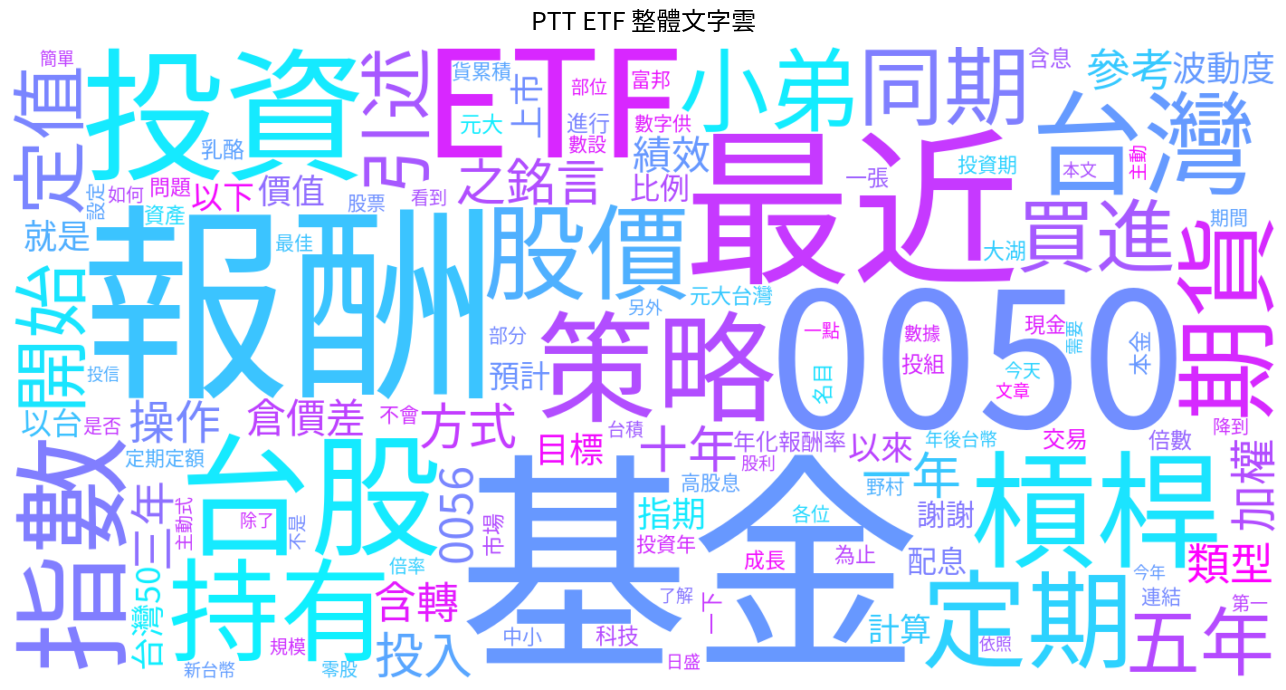


🏆 Top-20 tokens for [PTT ETF 整體文字雲]:
   基金　　　　　　　　  206
   報酬　　　　　　　　  166
   0050　　　　　　  131
   最近　　　　　　　　  105
   ETF　　　　　　　  80
   投資　　　　　　　　  73
   台股　　　　　　　　  62
   槓桿　　　　　　　　  57
   策略　　　　　　　　  51
   指數　　　　　　　　  50
   台灣　　　　　　　　  45
   持有　　　　　　　　  44
   定期　　　　　　　　  40
   股價　　　　　　　　  38
   期貨　　　　　　　　  38
   小弟　　　　　　　　  37
   同期　　　　　　　　  37
   買進　　　　　　　　  36
   開始　　　　　　　　  32
   定值　　　　　　　　  32


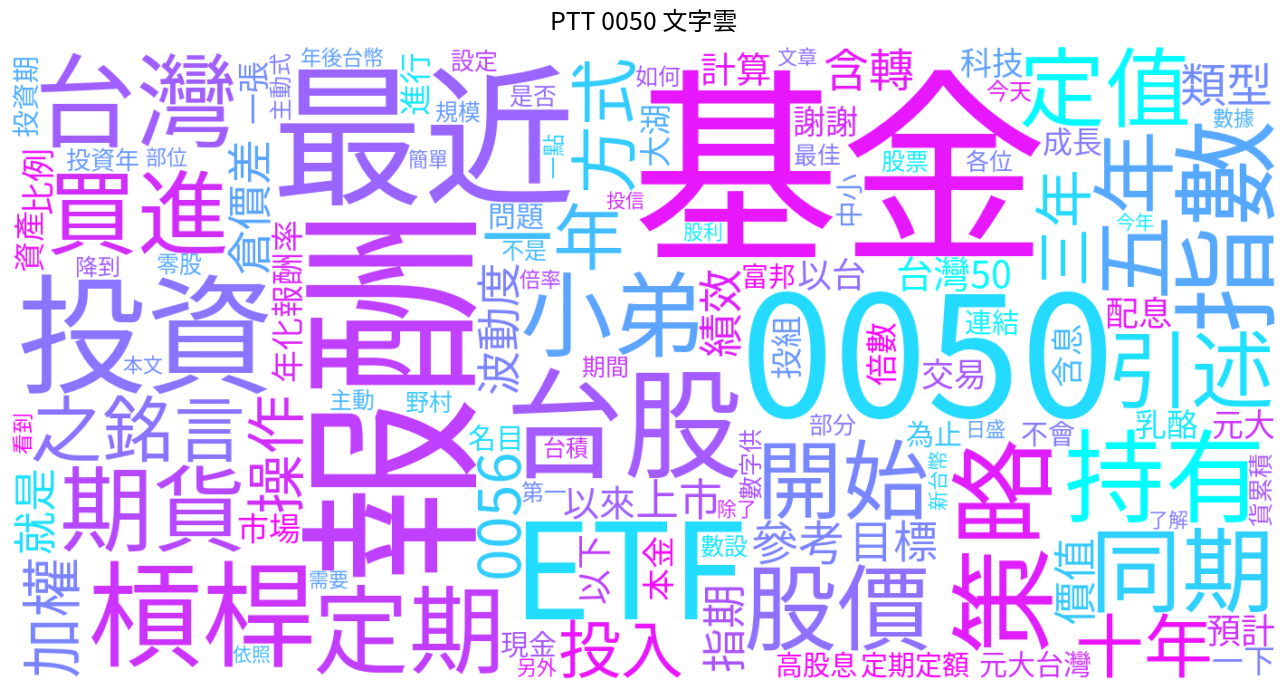


🏆 Top-20 tokens for [PTT 0050 文字雲]:
   基金　　　　　　　　  206
   報酬　　　　　　　　  166
   0050　　　　　　  131
   最近　　　　　　　　  105
   ETF　　　　　　　  80
   投資　　　　　　　　  73
   台股　　　　　　　　  62
   槓桿　　　　　　　　  57
   策略　　　　　　　　  51
   指數　　　　　　　　  50
   台灣　　　　　　　　  45
   持有　　　　　　　　  44
   定期　　　　　　　　  40
   股價　　　　　　　　  38
   期貨　　　　　　　　  38
   小弟　　　　　　　　  37
   同期　　　　　　　　  37
   買進　　　　　　　　  36
   開始　　　　　　　　  32
   定值　　　　　　　　  32


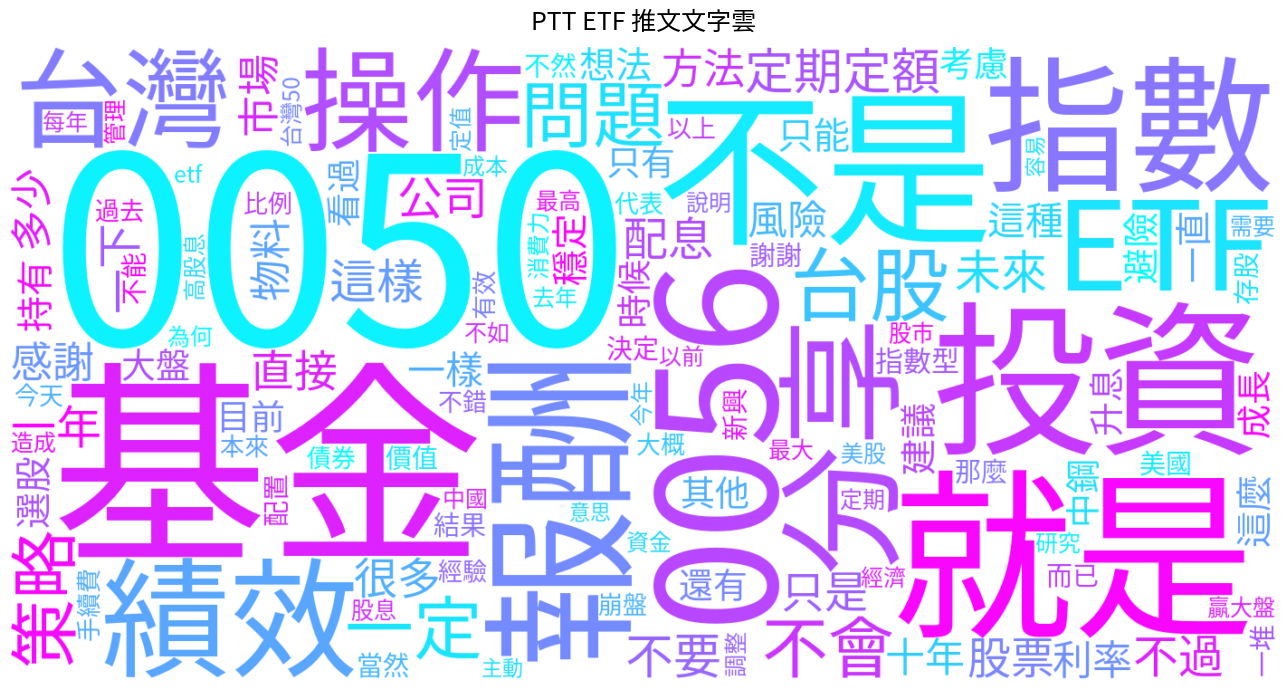


🏆 Top-20 tokens for [PTT ETF 推文文字雲]:
   0050　　　　　　  115
   基金　　　　　　　　  76
   就是　　　　　　　　  51
   不是　　　　　　　　  44
   0056　　　　　　  43
   投資　　　　　　　　  42
   報酬　　　　　　　　  39
   指數　　　　　　　　  36
   績效　　　　　　　　  29
   分享　　　　　　　　  29
   ETF　　　　　　　  27
   操作　　　　　　　　  27
   台灣　　　　　　　　  25
   台股　　　　　　　　  24
   問題　　　　　　　　  23
   一定　　　　　　　　  22
   策略　　　　　　　　  22
   不會　　　　　　　　  21
   定期定額　　　　　　  20
   不要　　　　　　　　  19


In [ ]:
# Cell 7 — Word Cloud (文字雲)
# ─────────────────────────────────────────────

# def find_cjk_font():
#     """找到 Colab 上可用的中文字型路徑"""
#     candidates = [
#         '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc',
#         '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
#         '/usr/share/fonts/truetype/noto/NotoSansCJKtc-Regular.otf',
#     ]
#     for path in candidates:
#         if os.path.exists(path):
#             return path
#     # fallback: 搜尋
#     import subprocess
#     result = subprocess.run(['fc-list', ':lang=zh'], capture_output=True, text=True)
#     for line in result.stdout.split('\n'):
#         if ':' in line:
#             return line.split(':')[0].strip()
#     return None


def make_wordcloud(token_series, title='Word Cloud'):
    """從 tokens Series 產生文字雲"""
    all_tokens = []
    for tl in token_series.dropna():
        if isinstance(tl, list):
            all_tokens.extend(tl)

    if not all_tokens:
        print(f"⚠️  No tokens available for: {title}")
        return

    freq = Counter(all_tokens)
    # font = find_cjk_font()

    wc = WordCloud(
        font_path,
        width=1400,
        height=700,
        background_color='white',
        max_words=120,
        colormap='cool',
        contour_width=0,
    ).generate_from_frequencies(freq)

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=18, pad=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    # 順便印出 Top-20 詞頻
    print(f"\n🏆 Top-20 tokens for [{title}]:")
    for word, count in freq.most_common(20):
        print(f"   {word:　<10s}  {count}")


if not df_articles.empty:
    # ── 整體文字雲 ──
    make_wordcloud(df_articles['tokens'], 'PTT ETF 整體文字雲')

    # ── 各關鍵字文字雲 ──
    for kw in KEYWORDS:
        mask = df_articles['search_keyword'].str.contains(kw, na=False)
        if mask.any():
            make_wordcloud(df_articles[mask]['tokens'], f'PTT {kw} 文字雲')

    # ── 推文文字雲 ──
    if not df_pushes.empty:
        make_wordcloud(df_pushes['tokens'], 'PTT ETF 推文文字雲')

In [ ]:
# Cell 8 — Export CSV & Summary
# ─────────────────────────────────────────────

if not df_articles.empty:
    # 匯出用欄位（移除中間產物 sentences）
    export_article_cols = [
        'article_id', 'artDate', 'title', 'author', 'content',
        'source_subreddit', 'search_keyword', 'url',
        'push_count', 'boo_count', 'arrow_count',
        'content_clean', 'tokens', 'sentiment', 'sentiment_label',
    ]
    df_export = df_articles[[c for c in export_article_cols if c in df_articles.columns]]
    df_export.to_csv('ptt_etf_articles.csv', index=False, encoding='utf-8-sig')

if not df_pushes.empty:
    df_pushes.to_csv('ptt_etf_pushes.csv', index=False, encoding='utf-8-sig')

# ── 印出摘要 ──
print('=' * 60)
print('📊  PTT ETF 輿情分析摘要')
print('=' * 60)

if not df_articles.empty:
    print(f"\n📰 文章總數: {len(df_articles)}")
    print(f"💬 推文總數: {len(df_pushes)}")

    print(f"\n── 各看板文章數 ──")
    print(df_articles['source_subreddit'].value_counts().to_string())

    print(f"\n── 各關鍵字文章數 ──")
    for kw in KEYWORDS:
        n = df_articles['search_keyword'].str.contains(kw, na=False).sum()
        print(f"   {kw}: {n}")

    print(f"\n── 情感分析 (per keyword) ──")
    for kw in KEYWORDS:
        mask = df_articles['search_keyword'].str.contains(kw, na=False)
        sub = df_articles[mask]
        if sub.empty:
            continue
        print(f"\n   🔹 {kw}  (n={len(sub)})")
        print(f"      Avg sentiment : {sub['sentiment'].mean():.3f}")
        print(f"      Positive      : {(sub['sentiment_label']=='positive').sum()}")
        print(f"      Neutral       : {(sub['sentiment_label']=='neutral').sum()}")
        print(f"      Negative      : {(sub['sentiment_label']=='negative').sum()}")

    if not df_pushes.empty:
        print(f"\n── 推文情感分佈 ──")
        print(df_pushes['sentiment_label'].value_counts().to_string())
else:
    print("⚠️  No articles were crawled. Check network / PTT availability.")

print(f"\n{'='*60}")
print("📁 Files saved: ptt_etf_articles.csv, ptt_etf_pushes.csv")
print('=' * 60)

# ── Colab 自動下載 ──
try:
    from google.colab import files
    files.download('ptt_etf_articles.csv')
    files.download('ptt_etf_pushes.csv')
    print("⬇️  Download triggered.")
except ImportError:
    print("💡 Not in Colab — CSV files saved to current directory.")

📊  PTT ETF 輿情分析摘要

📰 文章總數: 60
💬 推文總數: 1054

── 各看板文章數 ──
source_subreddit
Fund    60

── 各關鍵字文章數 ──
   0050: 60

── 情感分析 (per keyword) ──

   🔹 0050  (n=60)
      Avg sentiment : 0.085
      Positive      : 3
      Neutral       : 3
      Negative      : 54

── 推文情感分佈 ──
sentiment_label
negative    640
positive    266
neutral     148

📁 Files saved: ptt_etf_articles.csv, ptt_etf_pushes.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download triggered.


## 找出重要詞彙 - 以TFIDF為例

### 3.1 計算TF-IDF示範（公式）

In [ ]:
if 'df_articles' in locals() and not df_articles.empty:

    etf_df = pd.DataFrame({
        'doc': range(1, len(df_articles) + 1),
        'text': df_articles['content'].tolist()
    })

etf_df

,doc,text
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...
1,2,富人都在買！3檔主動ETF狂飆3成勝0050 達人揭「超額報酬」關鍵：潛藏2大風險\n\n旺...
2,3,最近想把0050連結基金轉倉成0050 etf\n\n查了一下國內基金贖回是T+1\n\n假...
3,4,https://myppt.cc/4lZRr9 26:06\n\n本來覺得陳威良先生講得還算...
4,5,昨天看台股有跌勢\n剛好有一筆資金進來\n就買回0050\n順便射飛標買了一些ETF\n包括...
5,6,三月份買的0050\n今天五月中\n資金另有它用\n暫時賣2張\n賣出這價還OK吧？！\n\...
6,7,1.原文連結：https://pse.is/4xuk62\n\n2.內容：\n\n國民ETF...
7,8,本身是新手\n\n想先從這兩筆穩健的ETF下手\n\n大家較推薦哪種方式啊\n\n定期定額還...
8,9,以前在Richart上買了定期定額的0050ETF\n最近覺得投資報酬率還滿理想的\n也有再...
9,10,※ [本文轉錄自 Stock 看板 #1WAEZVk0 ]\n\n作者: muzhu (蔡九...


####資料清理

In [ ]:
# etf_df['text'] = etf_df['text'].apply(lambda x: re.sub(r'[^\u4e00-\u9fff\w]+', '', str(x)))
etf_df = etf_df.assign(word = etf_df['text'].apply(lambda x: tokenize(x)[1])).explode('word')

etf_df.head(50)

,doc,text,word
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,0050
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,資產
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,規模
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,突破
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,億元
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,經理費率
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,降至
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,以下
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,中央社
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,記者


####計算各文章詞彙總數

In [ ]:
total_words = etf_df.groupby(['doc'], as_index=False).size().rename(columns={'size': 'total'})
total_words.head()

,doc,total
0,1,147
1,2,459
2,3,32
3,4,40
4,5,32


#### 計算各文章的各個詞彙數

In [ ]:
word_count = etf_df.groupby(['doc', 'word'], as_index = False).size()

word_count.rename(columns={'size': 'count'}, inplace=True)
word_count.sort_values('count', ascending=False).head()

,doc,word,count
709,10,基金,169
688,10,台灣,28
868,10,類型,23
95,2,ETF,20
632,10,ETF,18


合併需要的資料欄位
- 合併 **每個詞彙在每篇文章中出現的次數** 與 **每篇文章的詞數**

In [ ]:
etf_merged = word_count.merge(total_words, on = 'doc', how = 'left')
etf_merged.head(10)

,doc,word,count,total
0,1,0050,9,147
1,1,ETF,2,147
2,1,上市,1,147
3,1,不到,1,147
4,1,不斷,1,147
5,1,中央社,1,147
6,1,主要,1,147
7,1,之後進行,1,147
8,1,今天,3,147
9,1,今年,1,147


#### 計算 TF值

In [ ]:
# 計算tf = 詞彙在該文件中出現次數 / 該文件中詞彙總數
etf_tf_idf = etf_merged.assign(tf = etf_merged["count"] / etf_merged["total"])
etf_tf_idf.head()

,doc,word,count,total,tf
0,1,0050,9,147,0.061224
1,1,ETF,2,147,0.013605
2,1,上市,1,147,0.006803
3,1,不到,1,147,0.006803
4,1,不斷,1,147,0.006803


#### 計算 IDF值

In [ ]:
# 計算每個詞彙出現在幾篇文章中
idf_df = etf_merged.groupby(['word'], as_index = False).size()

# 合併到之前的df中
etf_tf_idf = etf_tf_idf.merge(idf_df, on = 'word', how = 'left')

etf_tf_idf.head()

,doc,word,count,total,tf,size
0,1,0050,9,147,0.061224,42
1,1,ETF,2,147,0.013605,21
2,1,上市,1,147,0.006803,11
3,1,不到,1,147,0.006803,3
4,1,不斷,1,147,0.006803,1


In [ ]:
import math
# 計算idf = log( 總文件數量 / 包含該詞彙的文件數量 )
etf_tf_idf = etf_tf_idf.assign(idf = etf_tf_idf["size"].apply(lambda size: math.log( len(total_words) / size, 10 ))).drop(["size"], axis=1)

etf_tf_idf.head()

,doc,word,count,total,tf,idf
0,1,0050,9,147,0.061224,0.154902
1,1,ETF,2,147,0.013605,0.455932
2,1,上市,1,147,0.006803,0.736759
3,1,不到,1,147,0.006803,1.301030
4,1,不斷,1,147,0.006803,1.778151


#### 計算 TFIDF值

In [ ]:
# 計算tf*idf
etf_tf_idf = etf_tf_idf.assign(tf_idf = etf_tf_idf["tf"] * etf_tf_idf["idf"])

etf_tf_idf.sort_values('tf_idf', ascending = False).head(10)

,doc,word,count,total,tf,idf,tf_idf
3649,52,分配,1,6,0.166667,1.778151,0.296359
3652,52,扣抵,1,6,0.166667,1.477121,0.246187
396,3,贖回,4,32,0.125000,1.778151,0.222269
474,6,這價還,1,9,0.111111,1.778151,0.197572
468,6,五月,1,9,0.111111,1.778151,0.197572
470,6,帳單,1,9,0.111111,1.778151,0.197572
467,6,三月份,1,9,0.111111,1.778151,0.197572
3653,52,稅率,1,6,0.166667,1.176091,0.196015
3650,52,去年,1,6,0.166667,1.176091,0.196015
3654,52,股息,1,6,0.166667,1.176091,0.196015


In [ ]:
# 選出每個文件，tf-idf值最大的前三個詞
group = etf_tf_idf.groupby("doc").apply(lambda x : x.nlargest(3, "tf_idf"))
group.head(12)

/tmp/ipykernel_8704/1996721822.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group = etf_tf_idf.groupby("doc").apply(lambda x : x.nlargest(3, "tf_idf"))


doc word  count  total        tf       idf    tf_idf
doc                                                          
1   14     1   億元      6    147  0.040816  1.778151  0.072578
    72     1   規模      8    147  0.054422  1.301030  0.070804
    64     1   突破      4    147  0.027211  1.477121  0.040194
2   112    2   主動      9    459  0.019608  1.477121  0.028963
    244    2  林正峰      7    459  0.015251  1.778151  0.027118
    114    2  主動式      8    459  0.017429  1.301030  0.022676
3   396    3   贖回      4     32  0.125000  1.778151  0.222269
    388    3   早上      2     32  0.062500  1.778151  0.111134
    389    3  星期一      2     32  0.062500  1.778151  0.111134
4   407    4   台積      2     40  0.050000  0.933053  0.046653
    402    4   中肯      1     40  0.025000  1.778151  0.044454
    403    4   乾脆      1     40  0.025000  1.778151  0.044454

### 3.2 應用於資料集（套件）

- Document term matrix (DTM)，是一種用於自然語言處理的數學矩陣，描述了在一組文件中各個詞彙出現的頻率。   
- DTM 中的每一行代表一個文件(Document)，每一列代表一個詞彙(Term)，每一格的值表示該詞彙在該文件中的出現次數。

In [ ]:
if 'df_articles' in locals() and not df_articles.empty:

    etfDTM_df = pd.DataFrame({
        'doc': range(1, len(df_articles) + 1),
        'text': df_articles['content'].tolist()
    })

etfDTM_df

,doc,text
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...
1,2,富人都在買！3檔主動ETF狂飆3成勝0050 達人揭「超額報酬」關鍵：潛藏2大風險\n\n旺...
2,3,最近想把0050連結基金轉倉成0050 etf\n\n查了一下國內基金贖回是T+1\n\n假...
3,4,https://myppt.cc/4lZRr9 26:06\n\n本來覺得陳威良先生講得還算...
4,5,昨天看台股有跌勢\n剛好有一筆資金進來\n就買回0050\n順便射飛標買了一些ETF\n包括...
5,6,三月份買的0050\n今天五月中\n資金另有它用\n暫時賣2張\n賣出這價還OK吧？！\n\...
6,7,1.原文連結：https://pse.is/4xuk62\n\n2.內容：\n\n國民ETF...
7,8,本身是新手\n\n想先從這兩筆穩健的ETF下手\n\n大家較推薦哪種方式啊\n\n定期定額還...
8,9,以前在Richart上買了定期定額的0050ETF\n最近覺得投資報酬率還滿理想的\n也有再...
9,10,※ [本文轉錄自 Stock 看板 #1WAEZVk0 ]\n\n作者: muzhu (蔡九...


In [ ]:
# 保留需要的欄位
etfDTM_df = etfDTM_df.loc[:, ["doc", "text"]]

# 改成使用空格連接斷完的詞
etfDTM_df['word'] = etfDTM_df.text.apply(lambda x: tokenize(x)[1]).map(' '.join)

etfDTM_df.head()

,doc,text,word
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,0050 資產 規模 突破 億元 經理費率 降至 以下 中央社 記者 曾仁凱 台北 日電 主...
1,2,富人都在買！3檔主動ETF狂飆3成勝0050 達人揭「超額報酬」關鍵：潛藏2大風險\n\n旺...,富人 檔主動 ETF 狂飆 成勝 0050 達人 超額 報酬 關鍵 潛藏 大風險 旺得 富理...
2,3,最近想把0050連結基金轉倉成0050 etf\n\n查了一下國內基金贖回是T+1\n\n假...,最近 0050 連結 基金 轉倉 0050 etf 一下 國內 基金 贖回 假設 萬元 連結...
3,4,https://myppt.cc/4lZRr9 26:06\n\n本來覺得陳威良先生講得還算...,本來 威良 先生 講得 還算 中肯 高股息 ETF 根本 垃圾 賠錢貨 聽到 出來 確貢獻 ...
4,5,昨天看台股有跌勢\n剛好有一筆資金進來\n就買回0050\n順便射飛標買了一些ETF\n包括...,昨天 台股 跌勢 剛好 一筆 資金 進來 0050 順便射 飛標 一些 ETF 包括 006...


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer
# Bag of Word
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(etfDTM_df["word"])
vocabulary = vectorizer.get_feature_names_out()

# 轉成 dataframe
DTM_df = pd.DataFrame(columns = vocabulary, data = X.toarray())
DTM_df

,0050,0056,006208,etf,一下,一並,一中,一二,一些,一來,...,高達,高配,鱗傷,鴻運,麻煩,黑馬,點數,點算,龍頭,龜苓
0,9,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,6,0,0,20,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
2,2,0,0,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,1,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,11,0,0,5,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
7,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,2,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,1,3,18,0,0,1,0,0,0,...,0,0,0,1,0,1,0,0,0,0


In [ ]:
transformer = TfidfTransformer()
# 將詞頻矩陣X統計成TF-IDF值
tfidf = transformer.fit_transform(X)

# 轉成dataframe
TFIDF_df = pd.DataFrame(columns = vocabulary, data = tfidf.toarray())

TFIDF_df

,0050,0056,006208,etf,一下,一並,一中,一二,一些,一來,...,高達,高配,鱗傷,鴻運,麻煩,黑馬,點數,點算,龍頭,龜苓
0,0.176433,0.000000,0.000000,0.056147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.064166,0.000000
1,0.061895,0.000000,0.000000,0.295458,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.030666,0.033765,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.090709,0.000000,0.000000,0.129902,0.091167,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.209175,0.000000,0.000000,0.074888,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.060332,0.000000,0.179354,0.086400,0.000000,0.000000,0.000000,0.000000,0.148369,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.121360,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.206282,0.000000,0.000000,0.134277,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.055748,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.124750,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.123389,0.000000,0.000000,0.088350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.009287,0.006683,0.027607,0.079794,0.000000,0.000000,0.010132,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.010132,0.000000,0.010132,0.000000,0.000000,0.000000,0.000000


###3.3 檢視結果

#### 方法1： 取每一個字詞在所有文件裡的TF-IDF平均值

In [ ]:
etf_tfidf = TFIDF_df.mean().to_frame().reset_index()
etf_tfidf.columns = ["word", "avg"]

etf_tfidf.sort_values('avg', ascending = False).head(10)

,word,avg
551,報酬,0.111519
1026,最近,0.095651
0,0050,0.078586
3,etf,0.046041
1092,槓桿,0.045810
548,基金,0.045364
838,投資,0.041635
1373,策略,0.038109
667,小弟,0.035120
22,一年,0.034666


#### 方法2： 取每份文件裡TF-IDF值最大的前10個字詞當為常用字詞，再取每一個字詞在常用字詞中出現頻率

In [ ]:
toptens = TFIDF_df.copy()
toptens.insert(0, 'doc_id', toptens.index+1)

toptens

,doc_id,0050,0056,006208,etf,一下,一並,一中,一二,一些,...,高達,高配,鱗傷,鴻運,麻煩,黑馬,點數,點算,龍頭,龜苓
0,1,0.176433,0.000000,0.000000,0.056147,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.064166,0.000000
1,2,0.061895,0.000000,0.000000,0.295458,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.030666,0.033765,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3,0.090709,0.000000,0.000000,0.129902,0.091167,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,4,0.209175,0.000000,0.000000,0.074888,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,5,0.060332,0.000000,0.179354,0.086400,0.000000,0.000000,0.000000,0.000000,0.148369,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,6,0.121360,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,7,0.206282,0.000000,0.000000,0.134277,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.055748,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,8,0.000000,0.000000,0.000000,0.124750,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,9,0.123389,0.000000,0.000000,0.088350,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,10,0.009287,0.006683,0.027607,0.079794,0.000000,0.000000,0.010132,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.010132,0.000000,0.010132,0.000000,0.000000,0.000000,0.000000


In [ ]:
toptens = toptens.melt(id_vars = "doc_id", var_name = "word", value_name = 'tfidf')
toptens

,doc_id,word,tfidf
0,1,0050,0.176433
1,2,0050,0.061895
2,3,0050,0.090709
3,4,0050,0.209175
4,5,0050,0.060332
...,...,...,...
113455,56,龜苓,0.000000
113456,57,龜苓,0.000000
113457,58,龜苓,0.000000
113458,59,龜苓,0.000000


nlargest() 會回傳指定列中最大的前x個值所對應的資料

In [ ]:
(
    # 從每篇文章挑選出tf-idf最大的前十個詞
    toptens.groupby("doc_id").apply(lambda x : x.nlargest(10, "tfidf")).reset_index(drop=True)

    # 計算每個詞被選中的次數
    .groupby(['word'],as_index=False).size()

).sort_values('size', ascending=False).head(10) # 排序看前十名

/tmp/ipykernel_8704/3561604680.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  toptens.groupby("doc_id").apply(lambda x : x.nlargest(10, "tfidf")).reset_index(drop=True)


,word,size
151,報酬,17
0,0050,15
258,最近,14
267,槓桿,12
278,波動度,9
316,策略,7
73,倉價差,6
3,etf,6
126,台股,6
130,含轉,6


### 透過 Jieba 斷詞與 N-gram 幫助建立斷詞字典

### 4.1 Bigram

In [ ]:
# 設定 ngram 斷詞 function
def ngram_getToken(row, n):
    # 進行斷詞
    seg_list = jieba.lcut(row)

    # 篩選掉停用字與字元數小於1的詞彙
    seg_list = [w for w in seg_list if w not in STOPWORDS and len(w)>1]

    # ngram斷詞
    seg_list = ngrams(seg_list, n)
    seg_list = [" ".join(w) for w in list(seg_list)]

    return seg_list

In [ ]:
from nltk.util import ngrams
if 'df_articles' in locals() and not df_articles.empty:
    etf_bigram = pd.DataFrame({
        'doc': range(1, len(df_articles) + 1),
        'text': df_articles['content'].tolist()
    })

    etf_bigram["word"] = etf_bigram['text'].apply(lambda row: ngram_getToken(row, 2))
    etf_bigram = etf_bigram.explode('word')

etf_bigram.head(3)

,doc,text,word
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,0050 資產
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,資產 規模
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,規模 突破


#### 統計最常出現的bigram組合

In [ ]:
# 計算每個組合出現的次數
etf_bigram_count = etf_bigram['word'].value_counts().reset_index()

etf_bigram_count.sort_values('count', ascending=False).head(10)

,word,count
0,定期 定值,32
1,台股 期貨,30
2,投資 報酬,27
3,11 20,26
4,報酬 指數,26
5,加權 股價,26
6,最近 十年,25
7,最近 五年,25
8,買進 持有,25
9,最近 一年,25


### 4.2 Trigram

In [ ]:
from nltk.util import ngrams
if 'df_articles' in locals() and not df_articles.empty:
    etf_trigram = pd.DataFrame({
        'doc': range(1, len(df_articles) + 1),
        'text': df_articles['content'].tolist()
    })

    etf_trigram["word"] = etf_trigram['text'].apply(lambda row: ngram_getToken(row, 3))
    etf_trigram = etf_trigram.explode('word')

etf_trigram.head(3)

,doc,text,word
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,0050 資產 規模
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,資產 規模 突破
0,1,0050資產規模突破7500億元 經理費率降至0.1%以下\n\n2025/10/2 19:...,規模 突破 7500


#### 統計最常出現的trigram組合

In [ ]:
# 計算每個組合出現的次數
etf_trigram_count = etf_trigram['word'].value_counts().reset_index()

etf_trigram_count.sort_values('count', ascending=False).head(10)

,word,count
1,股價 報酬 指數,24
0,加權 股價 報酬,24
6,買進 持有 含轉,22
4,含轉 倉價差 投資,22
5,持有 含轉 倉價差,22
2,報酬 指數 報酬,22
3,倉價差 投資 報酬,22
7,期貨 買進 持有,22
8,台股 期貨 買進,22
9,2018 11 20,15


### 4.4 Bigram視覺化

**更新斷詞字典**

In [ ]:
# 此處為手動微調區。若發現 Bigram 有應成對出現的詞，請加入此處
extra_words = [
    '加權股價報酬指數', '報酬指數', '加權股價', '股價報酬', '同期報酬',
    '定期定值', '定期定額', '買進持有', '台股期貨', '倉價差',
    '最近一年', '最近三年', '最近五年', '最近十年', '投資年', '投資期',
    '槓桿倍數', '含息報酬', '投組價值', '基金類型', '科技基金', '期貨累積'
]
for word in extra_words:
    jieba.add_word(word)

extra_stopwords = [
    '進行', '開始', '方式', '名目', '之銘言', '作者', '看板', '標題',
    '時間', '文章', '原文', '內容', '刪除', '推文', '心得', '乳酪',
    '小弟', '以下', '數設', '以台', '以來', '為止', '數字供', '引述'
]
for w in extra_stopwords:
    STOPWORDS.add(w)

print("自訂字典增補完成。")

# 3. 重新執行斷詞
if not df_articles.empty:
    df_articles[['content_clean', 'tokens']] = df_articles['content'].apply(
        lambda x: pd.Series(tokenize(x))
    )

if not df_pushes.empty:
    df_pushes[['content_clean', 'tokens']] = df_pushes['content'].apply(
        lambda x: pd.Series(tokenize(x))
    )

print("✅ 重新斷詞處理完成，現在您可以重新執行 TF-IDF 與 N-gram 分析。")

自訂字典增補完成。
✅ 重新斷詞處理完成，現在您可以重新執行 TF-IDF 與 N-gram 分析。


In [ ]:
from nltk.util import ngrams

if 'df_articles' in locals() and not df_articles.empty:
    etf_bigram = pd.DataFrame({
        'doc': range(1, len(df_articles) + 1),
        'tokens': df_articles['tokens'].tolist()
    })

    etf_bigram["word"] = etf_bigram['tokens'].apply(lambda x: [" ".join(bg) for bg in ngrams(x, 2)] if len(x) >= 2 else [])

    etf_bigram = etf_bigram.explode('word')

etf_bigram = etf_bigram.dropna(subset=['word'])
etf_bigram.head(3)

,doc,tokens,word
0,1,"[0050, 資產, 規模, 突破, 億元, 經理費率, 降至, 中央社, 記者, 曾仁凱,...",0050 資產
0,1,"[0050, 資產, 規模, 突破, 億元, 經理費率, 降至, 中央社, 記者, 曾仁凱,...",資產 規模
0,1,"[0050, 資產, 規模, 突破, 億元, 經理費率, 降至, 中央社, 記者, 曾仁凱,...",規模 突破


In [ ]:
from nltk import FreqDist
etf_bigram['word'] = etf_bigram['word'].astype(str)

# 使用FreqDist 取得 bigram 斷詞 與 bigram出現頻率
etf_bigram = FreqDist(etf_bigram['word'].apply(lambda x: tuple(x.split(' '))))
etf_bigram.most_common(50)

[(('報酬', '同期'), 37),
 (('投資', '報酬'), 27),
 (('最近一年', '最近三年'), 25),
 (('最近三年', '最近五年'), 25),
 (('最近五年', '最近十年'), 25),
 (('台股期貨', '買進持有'), 22),
 (('買進持有', '含轉'), 22),
 (('含轉', '倉價差'), 22),
 (('倉價差', '投資'), 22),
 (('加權股價報酬指數', '報酬'), 22),
 (('基金', '類型'), 21),
 (('0050', '報酬'), 16),
 (('報酬', '波動度'), 15),
 (('同期', '0050'), 15),
 (('0050', '含息'), 14),
 (('波動度', '最近一年'), 14),
 (('最近十年', '上市'), 14),
 (('定期定值', '目標'), 14),
 (('定期定值', '策略'), 14),
 (('策略', '槓桿倍數'), 14),
 (('槓桿倍數', '報酬'), 14),
 (('含息', '投資年'), 12),
 (('投資年', '報酬'), 12),
 (('上市', '定期定值'), 12),
 (('預計', '期貨累積'), 12),
 (('投組價值', '報酬'), 11),
 (('期貨累積', '本金'), 11),
 (('本金', '槓桿倍數'), 11),
 (('槓桿倍數', '設為'), 11),
 (('投資期', '策略'), 11),
 (('同期', '台股期貨'), 11),
 (('同期', '加權股價報酬指數'), 11),
 (('報酬', '參考'), 11),
 (('參考', '加權股價報酬指數'), 11),
 (('報酬', '台股期貨'), 11),
 (('報酬', '最近一年'), 11),
 (('目標', '年後台幣'), 10),
 (('年後台幣', '投組價值'), 10),
 (('ETF', '基金'), 9),
 (('連結', '基金'), 9),
 (('中小', '基金'), 9),
 (('基金', '新台幣'), 9),
 (('最佳', '倍率'), 9),
 (('台股', '基金'),

In [ ]:
d = {k:v for k,v in etf_bigram.most_common(50)}

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
# Create network plot
G = nx.Graph()

# 建立 nodes 間的連結
for k, v in [d][0].items():
    G.add_edge(k[0], k[1], weight=v) # nodes：詞彙，weight：組合出現頻率

# 取得調整edge權重
weights = [w[2]['weight']*0.01 for w in  G.edges(data=True)]

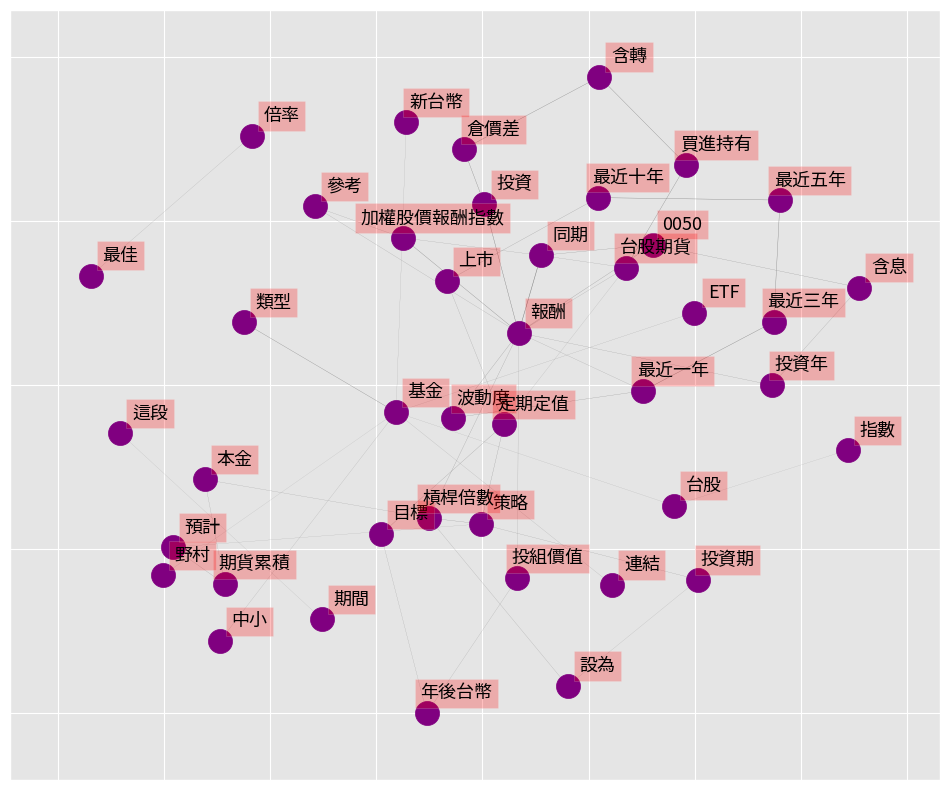

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

pos = nx.spring_layout(G, k=1.5)

# networks
nx.draw_networkx(G, pos,
                 font_size=16,
                 width=weights,
                 edge_color='grey',
                 node_color='purple',
                 with_labels = False,
                 ax=ax)

# 增加 labels
for key, value in pos.items():
    x, y = value[0]+.07, value[1]+.045
    ax.text(x, y,
            s=key,
            bbox=dict(facecolor='red', alpha=0.25),
            horizontalalignment='center', fontsize=13)

plt.show()

## Pairwise correlation
計算兩個詞彙間的相關性 Pearson correlation

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1. 篩選出現在至少 5 篇文章以上且詞頻前 300 的詞彙
docs = df_articles['content_clean'].fillna('').tolist()
vectorizer = CountVectorizer(min_df=5, max_features=300)
X = vectorizer.fit_transform(docs)
vocabulary = vectorizer.get_feature_names_out()

# 2. 轉成 DataFrame
DTM_df = pd.DataFrame(columns=vocabulary, data=X.toarray())
DTM_df

,0050,0056,etf,一下,一些,一張,一直,一點,上市,不是,...,配息,金融,除了,除息,零股,需要,預計,風險,高手,高股息
0,9,0,2,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,6,0,20,0,0,0,0,0,4,2,...,3,1,1,0,1,0,2,1,0,0
2,2,0,2,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,1,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,11,0,5,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,2,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,1,18,0,0,0,0,0,0,0,...,6,1,0,0,0,0,0,0,0,6


In [ ]:
# 3. 計算詞之間的相關係數
corr_matrix = np.corrcoef(DTM_df.T)

# 4. 轉成 DataFrame 並整理格式
Cor_df = pd.DataFrame(corr_matrix, index=DTM_df.columns, columns=DTM_df.columns)
Cor_df.insert(0, 'word1', Cor_df.columns)
Cor_df.reset_index(inplace=True, drop=True)
Cor_df

,word1,0050,0056,etf,一下,一些,一張,一直,一點,上市,...,配息,金融,除了,除息,零股,需要,預計,風險,高手,高股息
0,0050,1.000000,0.203607,0.244709,-0.062142,-0.097375,0.158229,0.124972,-0.134668,0.490727,...,0.259497,0.291537,0.077074,-0.116616,1.636486e-01,0.058527,-0.178045,-0.093910,0.121265,0.187593
1,0056,0.203607,1.000000,0.012913,0.196271,-0.076687,-0.007534,0.407480,-0.038344,-0.107479,...,0.406301,0.078459,-0.079987,-0.004248,1.664111e-02,-0.012450,-0.109089,-0.014130,0.193643,0.257713
2,etf,0.244709,0.012913,1.000000,-0.116971,-0.066797,0.007656,-0.072485,-0.016699,0.351066,...,0.738617,0.573002,0.187725,0.007401,1.666912e-01,0.039763,0.113185,0.301540,-0.056223,0.535777
3,一下,-0.062142,0.196271,-0.116971,1.000000,-0.016328,-0.008556,0.466783,0.669438,-0.022884,...,0.007776,-0.107940,-0.119212,-0.101311,-1.417250e-02,-0.111335,-0.039622,0.505428,0.008457,-0.024847
4,一些,-0.097375,-0.076687,-0.066797,-0.016328,1.000000,0.130999,-0.095249,-0.090909,-0.127412,...,-0.086589,-0.085855,0.284463,-0.080582,1.104728e-01,0.265665,0.053249,-0.100504,0.047088,-0.069171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,需要,0.058527,-0.012450,0.039763,-0.111335,0.265665,0.305483,-0.092783,-0.088555,-0.124113,...,-0.014058,0.380988,0.044472,-0.078496,3.843291e-01,1.000000,0.170431,-0.097901,-0.091738,0.157221
143,預計,-0.178045,-0.109089,0.113185,-0.039622,0.053249,-0.118585,-0.135493,-0.083677,0.138599,...,0.039850,0.021552,-0.029093,-0.114630,-3.301456e-02,0.170431,1.000000,0.109329,-0.133967,-0.098397
144,風險,-0.093910,-0.014130,0.301540,0.505428,-0.100504,-0.092161,0.195561,0.703526,0.140859,...,0.083762,0.221470,0.011648,0.022272,7.689715e-17,-0.097901,0.109329,1.000000,-0.104116,-0.076472
145,高手,0.121265,0.193643,-0.056223,0.008457,0.047088,0.191223,0.641370,0.188353,-0.131991,...,-0.005606,-0.088940,0.065486,-0.005217,1.634902e-01,-0.091738,-0.133967,-0.104116,1.000000,-0.026872


In [ ]:
# 5. 轉換為一維的成對格式
word_cor_df = Cor_df.melt(id_vars = 'word1', var_name = 'word2', value_name = 'cor')

# 6. 去除兩個詞相同的情況
word_cor_df = word_cor_df[word_cor_df["word1"] != word_cor_df["word2"]]
word_cor_df.sort_values('cor', ascending=False).head(30)


,word1,word2,cor
13170,最近一年,最近五年,1.000000
13173,最近十年,最近五年,1.000000
13025,最近五年,最近三年,1.000000
12877,最近三年,最近一年,1.000000
12878,最近五年,最近一年,1.000000
13026,最近十年,最近三年,1.000000
13317,最近一年,最近十年,1.000000
13171,最近三年,最近五年,1.000000
13319,最近五年,最近十年,1.000000
12879,最近十年,最近一年,1.000000


### 5.1 和 「0050」, 「配息」 相關性最高的 10 個詞彙

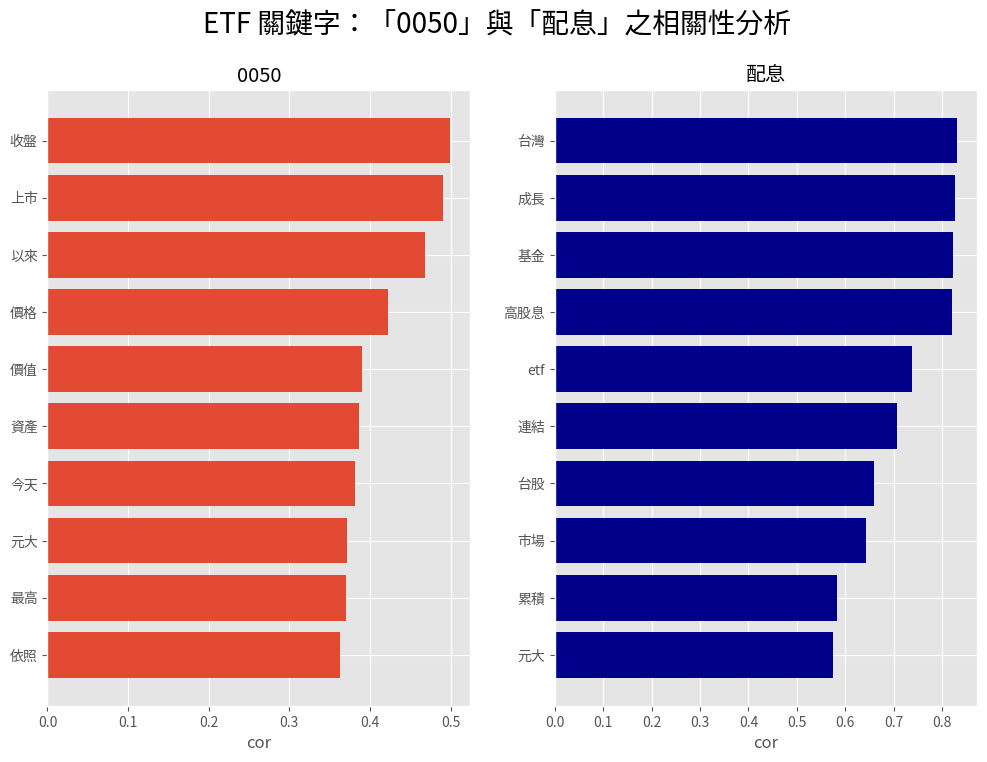

In [ ]:
keyword1 = "0050"
keyword2 = "配息"

kw1_sum = word_cor_df[(word_cor_df["word1"] == keyword1)].sort_values(by=['cor'], ascending=False).head(10)
kw2_sum = word_cor_df[(word_cor_df["word1"] == keyword2)].sort_values(by=['cor'], ascending=False).head(10)

plt.figure(figsize=(12,8))
plt.style.use("ggplot")

plt.suptitle(f'ETF 關鍵字：「{keyword1}」與「{keyword2}」之相關性分析', fontsize=20, fontweight='bold')

plt.subplot(121)
plt.title(keyword1)
plt.xlabel('cor')
plt.barh(kw1_sum['word2'], kw1_sum['cor'])
plt.gca().invert_yaxis()

plt.subplot(122)
plt.title(keyword2)
plt.xlabel('cor')
plt.barh(kw2_sum['word2'], kw2_sum['cor'], color="darkblue")
plt.gca().invert_yaxis()

plt.show()

### 5.2 使用詞彙關係圖畫出以詞頻前 60 為節點且相關性高於 0.3 的組合

In [ ]:
# 1. 透過 DTM 找出詞頻前 60 高的詞彙
most_freq_df = DTM_df.sum().sort_values(ascending=False).head(60).reset_index().rename(columns={'index':'word', 0:'count'})
most_freq_word = most_freq_df['word'].tolist()

# 2. 保留存在詞頻前 60 高之詞彙的組合
filtered_df = word_cor_df[(word_cor_df['word1'].isin(most_freq_word)) & (word_cor_df['word2'].isin(most_freq_word))]

# 3. 篩選出相關係數大於 0.3 的組合
# 重置 index 避免迴圈抓不到對應的 key
filtered_df = filtered_df[filtered_df['cor'] > 0.3].reset_index(drop=True)
filtered_df

,word1,word2,cor
0,上市,0050,0.490727
1,以來,0050,0.468177
2,價值,0050,0.390259
3,元大,0050,0.371770
4,台股,0050,0.362598
...,...,...,...
985,槓桿,預計,0.467229
986,為止,預計,0.883779
987,策略,預計,0.742164
988,績效,預計,0.306384


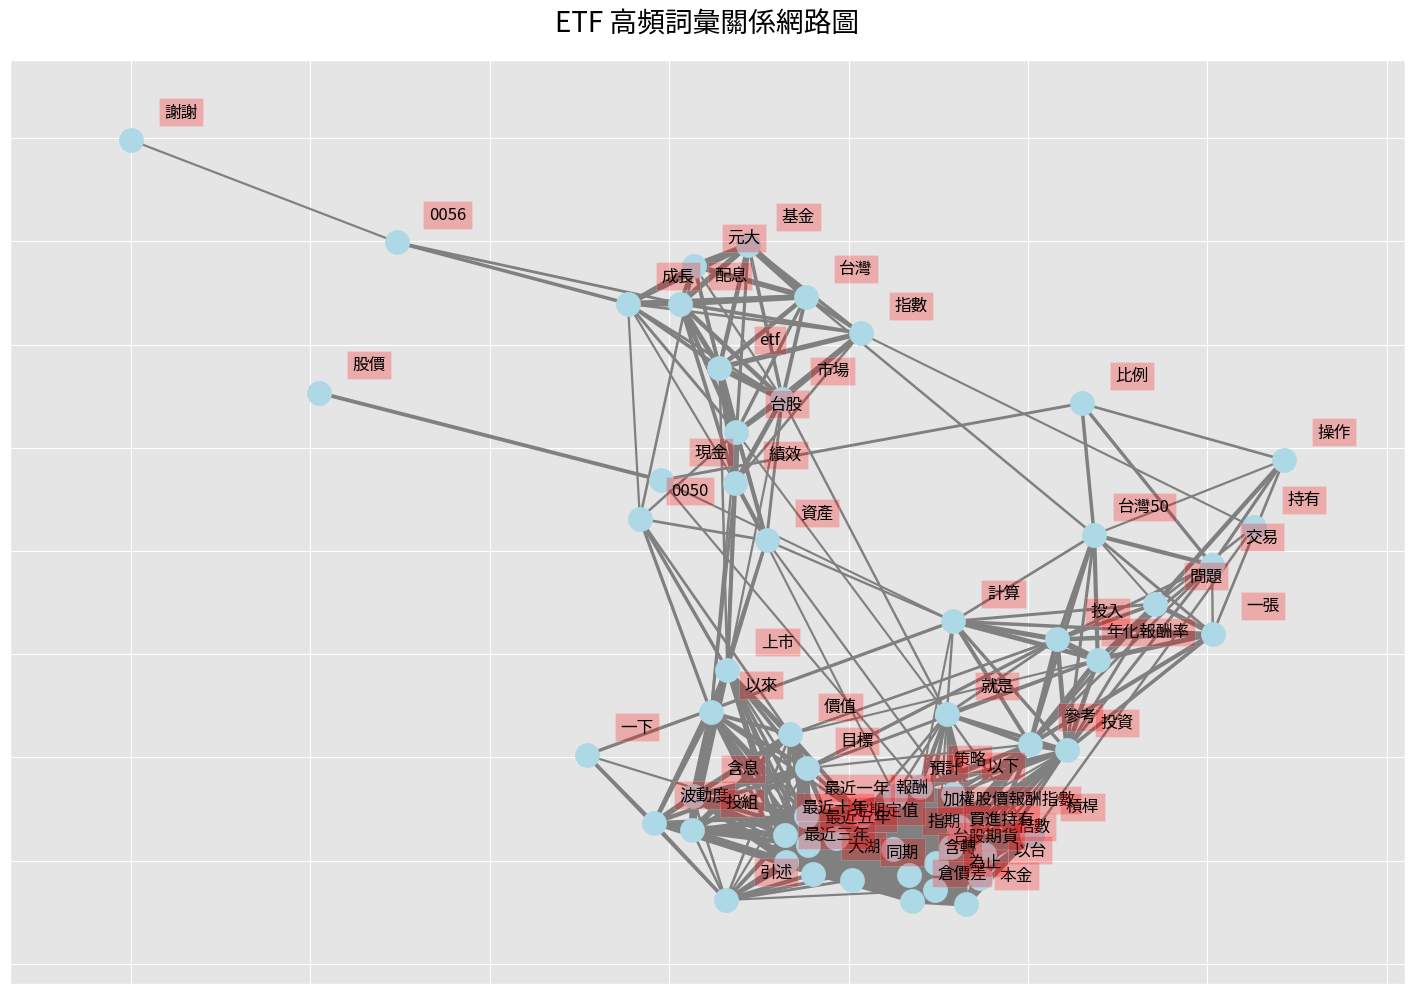

In [ ]:
# 4. 建立 network plot
g = nx.Graph()

# 建立 nodes 間的連結
for i in range(len(filtered_df)):
    g.add_edge(filtered_df["word1"][i], filtered_df["word2"][i], weight=filtered_df["cor"][i])

# 取得 edge 權重
weights = [w[2]['weight']*5 for w in g.edges(data=True)]

fig, ax = plt.subplots(figsize=(18, 12))
pos = nx.spring_layout(g, k=0.3)

# networks
nx.draw_networkx(g, pos,
            font_family='NotoSansCJK',
            font_size=16,
            width=weights,
            edge_color='grey',
            node_color='lightblue',
            with_labels=False,
            ax=ax)

# 增加 labels
for key, value in pos.items():
    x, y = value[0]+.07, value[1]+.045
    ax.text(x, y,
        s=key,
        fontfamily='NotoSansCJK',
        bbox=dict(facecolor='red', alpha=0.25),
        horizontalalignment='center', fontsize=12)

plt.title(f'ETF 高頻詞彙關係網路圖', fontsize=20, fontweight='bold', pad=20)
plt.show()

## 計算文章相似度 (TF-IDF & Cosine Similarity)
以 TF-IDF 的結果當作文章的向量，計算 Cosine Similarity 找出相似的文章    

In [ ]:
data_cos = df_articles.copy()

# 1. 將詞頻矩陣 X 統計成 TF-IDF 值
transformer = TfidfTransformer()
print(transformer)
tfidf = transformer.fit_transform(X)

# 轉成 DataFrame
TFIDF_df = pd.DataFrame(columns=vocabulary, data=tfidf.toarray())
TFIDF_df

TfidfTransformer()


,0050,0056,etf,一下,一些,一張,一直,一點,上市,不是,...,配息,金融,除了,除息,零股,需要,預計,風險,高手,高股息
0,0.423667,0.000000,0.134826,0.000000,0.000000,0.000000,0.000000,0.000000,0.091589,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.107999,0.000000,0.515538,0.000000,0.000000,0.000000,0.000000,0.000000,0.140084,0.077715,...,0.121285,0.044265,0.040428,0.000000,0.044265,0.000000,0.072363,0.042209,0.000000,0.000000
2,0.200139,0.000000,0.286613,0.201150,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.601131,0.000000,0.215215,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.369575
4,0.158859,0.000000,0.227496,0.000000,0.390665,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.248421,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.448683,0.000000,0.292065,0.000000,0.000000,0.000000,0.000000,0.000000,0.079361,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.211351,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.206672,0.000000,0.147984,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.010459,0.007526,0.089864,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.046981,0.008573,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.051439


In [ ]:
# 2. 計算文章間的 cosine similarity
cosine_matrix = cosine_similarity(tfidf.toarray(), tfidf.toarray())

# 3. 檢視與「第一篇」文章 (index=0) 相似的文章
cos_df = pd.DataFrame(cosine_matrix[0], columns=['cos_similarity'])

# 4. 把原始文章資料 (df_articles) 併進來顯示標題
cos_df = cos_df.merge(df_articles, how='left', left_index=True, right_index=True)

cos_df = pd.DataFrame(cosine_matrix[0], columns = ['cos_similarity'])
cos_df

,cos_similarity
0,1.000000
1,0.378522
2,0.266679
3,0.283696
4,0.262958
5,0.268744
6,0.429452
7,0.028496
8,0.291192
9,0.279943


In [ ]:
# 列出相似度最高的前 10 篇
cos_df = cos_df.merge(data_cos, how = 'left', left_index=True, right_index=True)
print("相似度最高的前 10 篇:")
cos_df.loc[:, ["cos_similarity", "title"]].sort_values(by=['cos_similarity'], ascending=False).head(10)

相似度最高的前 10 篇:


,cos_similarity,title
0,1.000000,[新聞] 0050資產規模突破7500億元 經理費率降
6,0.429452,[新聞] 0050尋找6月壽星！元大投信祭終身免手續
1,0.378522,[新聞] 富人都在買！3檔主動ETF狂飆3成勝0050
8,0.291192,[問題] 定期定額0050ETF還會做波段嗎？
3,0.283696,[心得] 2330不漲0050也不漲？
9,0.279943,Fw: [其他] 2020台股基金ETF績效大亂鬥0050.006208
46,0.279783,[問題] 0050的報酬率
43,0.276448,[問題] 綠角 0050 投資
5,0.268744,[心得] 今天賣0050ETF
2,0.266679,[討論] 0050連結基金無縫轉倉0050 etf?


### PTT ETF 輿情分析的實質發現總結

**一、 核心輿情：投資人從「看漲跌」轉向「看成本」**

從詞頻統計與文字雲的結果顯示，0050 的討論核心已不再僅限於股價漲跌，而是高度集中在「規模」、「費率」、「基金」與「經理費」。

**二、 情緒表現：熱度高漲下的「群體焦慮」**

雖然 ETF 市場極度火熱，但情緒分析（SnowNLP）的量化結果顯示，負面與中立情緒佔比顯著高於正面情緒（在 60 篇文章中，負面標籤高達 54 篇）。

數據揭示：這種「高聲量、低情緒」的現象，反映出鄉民在台股創新高之際，對於「進場時機」、「高點回檔」以及「配息是否縮水」存有集體的焦慮感。社群討論的動能更多來自於對風險的觀望與成本的斤斤計較。

**三、 討論結構：散戶思維的「法人化」趨勢**

透過 Bigram 與共線圖分析發現，詞彙間的關聯呈現高度邏輯化。

數據揭示：討論中頻繁出現「報酬-波動度」、「含息-總報酬」、「長期-回測」等組合。這證明 PTT 鄉民在評估 ETF 時，已經跳脫單純的「殖利率」陷阱，轉向追求「含息總報酬」與「風險穩定性」的理性評估。此外，將 0050 與「台股期貨」及「槓桿策略」並論，顯示投資人的工具箱正趨於複雜化。

## 接續：PTT Stock 文章面向分類

以下內容直接接續本 notebook，保留原先已執行完成的 cells 與 outputs，不另行重跑。


# PTT Stock 文章面向分類

本 notebook 參考 [week7_classification_zh_udn.ipynb](./week7_classification_zh_udn.ipynb) 之分析流程，改以 PTT Stock 板文章為研究語料，建立文章面向分類模型。

## 分析目標
- 資料來源：`ptt_stock_articles_clean.csv`
- 候選文章：原始 `title_tag` 為 `新聞`、`情報`、`標的`
- 最終分類標籤：`消息面`、`基本面`、`技術籌碼面`

## 研究設計
原始 `title_tag` 主要反映文章形式，無法直接代表文章所採用之分析面向。因此，本研究先以規則式方法建立作業版標籤，再透過監督式分類模型學習文章內容與面向之對應關係。


## 1. 套件說明

若需於本機重現本 notebook，可使用下列指令啟動環境：

```bash
uv run --with pandas --with jieba --with scikit-learn --with matplotlib --with notebook jupyter notebook
```


In [ ]:
from __future__ import annotations

import re
import warnings
from pprint import pprint

import jieba
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import cross_validate, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "Heiti TC", "Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
# 若需要重建這份作業版標註資料，可取消下面註解後先執行：
# !uv run python prepare_ptt_stock_facet_dataset.py --input ptt_stock_articles_clean.csv --output ptt_stock_articles_facets.csv --min-margin 1

ptt_df = pd.read_csv("ptt_stock_articles_facets.csv")
ptt_df["post_datetime"] = pd.to_datetime(ptt_df["post_datetime"])

print(f"rows: {len(ptt_df)}")
print(f"date range: {(ptt_df['post_datetime'].min(), ptt_df['post_datetime'].max())}")
display(ptt_df.head(3))

rows: 5235
date range: (Timestamp('2026-01-01 11:43:13'), Timestamp('2026-04-15 23:57:10'))


,post_datetime,title,title_tag,content_raw,crawl_datetime,facet_label,facet_margin
0,2026-04-15 20:49:01,日月光半導體以148.5億元買群創南科5廠,新聞,原文標題： 日月光半導體以148.5億元買群創南科5廠\n原文連結：https://ec.l...,2026-04-16T03:31:45+08:00,消息面,5
1,2026-04-15 21:07:12,0050 元大台灣50 大盤報酬試算,標的,我就喜歡參與討論\n問題如下，現在37000進場會不會太貴？\n貴！就是貴！\n現在如果等著...,2026-04-16T03:31:45+08:00,技術籌碼面,4
2,2026-04-15 21:09:39,預估每人分紅1500萬！南韓高工畢業生直呼,新聞,預估每人分紅1500萬！南韓高工畢業生直呼SK海力士讓生活變美好\nhttps://ec.l...,2026-04-16T03:31:45+08:00,消息面,1


## 1.1 上標流程與邏輯

由於本研究的最終標籤 `消息面 / 基本面 / 技術籌碼面` 並非原始資料直接提供，因此先以規則式方法建立作業版標註。其流程如下：

1. 僅保留原始 `title_tag` 為 `新聞`、`情報`、`標的` 的文章。
2. 依原始 `title_tag` 給予一組弱先驗分數。
3. 掃描標題與內文，若命中對應面向關鍵字，則為該面向加 1 分。
4. 以總分最高者作為 `facet_label`。
5. 若最高分與第二高分之差距小於 `facet_margin = 1`，則視為文章面向不明確，予以排除。

在規則設計上，本研究僅保留能反映內容面向的關鍵詞。例如 `原文連結`、`發布時間`、`記者署名` 等新聞轉貼格式，以及 `獲利`、`庫存`、`持股`、`突破`、`進場` 等過於泛用的詞彙，均不直接作為上標依據，以降低模板訊號與口語慣用語對標註結果的干擾。


In [ ]:
from prepare_ptt_stock_facet_dataset import DEFAULT_KEEP_TAGS, FACET_KEYWORDS, TAG_PRIORS, compute_facet_scores

print(f"keep tags: {DEFAULT_KEEP_TAGS}")
display(pd.DataFrame(TAG_PRIORS).T)

keyword_df = pd.DataFrame({facet: pd.Series(list(patterns)) for facet, patterns in FACET_KEYWORDS.items()})
display(keyword_df.head(15))


keep tags: ('新聞', '情報', '標的')


,消息面,基本面,技術籌碼面
新聞,2,0,0
情報,0,1,1
標的,0,1,2


,消息面,基本面,技術籌碼面
0,法說,營收,外資
1,法說會,月營收,投信
2,重訊,年增,自營
3,重大訊息,季增,主力
4,公告,自結,分點
5,董事會,EPS,融資
6,決議,每股盈餘,融券
7,併購,本益比,借券
8,收購,毛利,買超
9,處分,毛利率,賣超


### 上標規則示意

- `新聞` 文章僅給予 `消息面` 弱先驗，不直接將新聞格式等同於消息面。
- `標的` 文章先對 `技術籌碼面` 與 `基本面` 給予較弱的起始分數，因其內容常同時混合操作與分析。
- 若文章中出現 `營收 / EPS / 本益比 / 毛利率 / 配息 / ROE` 等詞，則提高 `基本面` 分數。
- 若文章中出現 `外資 / 融資 / 均線 / 停損 / 買超 / 支撐 / KD` 等詞，則提高 `技術籌碼面` 分數。
- 若文章中出現 `法說 / 重訊 / 董事會 / 關稅 / 升息 / 聯準會 / 戰爭` 等詞，則提高 `消息面` 分數。
- `原文連結 / 發布時間 / 記者署名 / 持股 / 進場 / 突破` 等格式詞或過泛詞不納入任何面向關鍵字。


In [ ]:
example_row = ptt_df.loc[0, ["title_tag", "title", "content_raw", "facet_label", "facet_margin"]]
scores = compute_facet_scores(
    title_tag=example_row["title_tag"],
    title=example_row["title"],
    content_raw=example_row["content_raw"],
)

print(example_row[["title_tag", "title", "facet_label", "facet_margin"]])
print()
print("facet scores:")
pprint(scores)


title_tag                          新聞
title           日月光半導體以148.5億元買群創南科5廠
facet_label                       消息面
facet_margin                        5
Name: 0, dtype: object

facet scores:
{'基本面': 2, '技術籌碼面': 0, '消息面': 7}


## 2. 文字前處理

本研究沿用課堂 notebook 的基本前處理流程，但保留英數字資訊，原因在於 PTT 股板文章常出現 `0050`、`EPS`、`Q1`、股票代號與數值資料，這些內容對面向分類具有辨識價值。另為避免模型將單獨出現的年份（例如民國 `114` 年或西元 `2025` 年）誤判為內容面向特徵，本文亦於斷詞階段排除此類年份 token；同時，`標的 / 分類 / 正文 / 機制 / 心得 / 評論 / 記者 / 分析 / 討論 / 報導 / 快訊` 等較偏向貼文格式、評論段落標頭、新聞形式或報導署名之字詞，也不納入模型特徵。


### 2.1 清理

首先將標題與內文合併為分析文本，並在清理階段先移除新聞轉貼常見的模板欄位，例如 `原文標題`、`原文連結`、`發布時間`、`記者署名` 等；其後再移除網址與多餘符號，保留中文、英文字母與數字。


In [ ]:
TEMPLATE_DROP_LABELS = (
    "原文標題",
    "原新聞標題",
    "原文連結",
    "發布時間",
    "記者署名",
    "媒體來源",
    "完整新聞標題",
    "來源",
    "網址",
)

TEMPLATE_KEEP_REMAINDER_LABELS = (
    "原文內容",
    "完整新聞內文",
)


def strip_template_fields(text: str) -> str:
    cleaned_lines = []
    for line in str(text).splitlines():
        stripped = line.strip()
        if not stripped:
            continue

        keep_remainder = False
        for label in TEMPLATE_KEEP_REMAINDER_LABELS:
            if re.match(rf"^{label}\s*[:：]", stripped):
                remainder = re.split(r"[:：]", stripped, maxsplit=1)[1].strip()
                if remainder:
                    cleaned_lines.append(remainder)
                keep_remainder = True
                break
        if keep_remainder:
            continue

        if any(re.match(rf"^{label}\s*[:：]", stripped) for label in TEMPLATE_DROP_LABELS):
            continue

        cleaned_lines.append(stripped)

    return "\n".join(cleaned_lines)


def preprocess_text(text: str) -> str:
    text = strip_template_fields(str(text))
    text = re.sub(r"(http|https)://\S+", " ", text)
    text = re.sub(r"[^0-9A-Za-z\u4e00-\u9fa5]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


ptt_df["content_raw_clean"] = ptt_df["content_raw"].fillna("").map(strip_template_fields)
ptt_df["content"] = ptt_df["title"].fillna("") + "\n" + ptt_df["content_raw_clean"]
ptt_df["content"] = ptt_df["content"].map(preprocess_text)
ptt_df.loc[:2, ["title", "facet_label", "content"]]


,title,facet_label,content
0,日月光半導體以148.5億元買群創南科5廠,消息面,日月光半導體以148 5億元買群創南科5廠 日月光投控 3711 為了擴增AI需求的先進封裝...
1,0050 元大台灣50 大盤報酬試算,技術籌碼面,0050 元大台灣50 大盤報酬試算 我就喜歡參與討論 問題如下 現在37000進場會不會太...
2,預估每人分紅1500萬！南韓高工畢業生直呼,消息面,預估每人分紅1500萬 南韓高工畢業生直呼 預估每人分紅1500萬 南韓高工畢業生直呼SK海...


### 2.2 斷詞

本文採用與課堂範例相同的 `jieba` 流程進行中文斷詞，並套用停用詞表。


In [ ]:
jieba.set_dictionary("./dict/dict.txt.big")
with open("./dict/stop_words.txt", encoding="utf-8") as f:
    stop_words = {line.strip() for line in f if line.strip()}

extra_stop_words = {
    "標的", "分類", "正文", "機制", "心得", "評論", "記者", "分析", "討論", "報導", "快訊"
}


def is_year_token(token: str) -> bool:
    return bool(re.fullmatch(r"(?:19|20)\d{2}|1[0-2]\d", token))


def get_tokens(text: str) -> list[str]:
    seg_list = jieba.cut(text, cut_all=False)
    return [
        w for w in seg_list
        if w not in stop_words
        and w not in extra_stop_words
        and len(w) > 1
        and not is_year_token(w)
    ]


ptt_df["words"] = ptt_df["content"].map(get_tokens).map(" ".join)
ptt_df.loc[:2, ["title", "facet_label", "words"]]


Building prefix dict from /Users/chenqien/Documents/碩一下/社群媒體分析/SMA_2026S-main/week07/dict/dict.txt.big ...


Dumping model to file cache /var/folders/hz/rkgx10wj74j9dswg6f028cdh0000gn/T/jieba.ue4760a6d46f5ad10d756e4b3818fa766.cache


Loading model cost 0.616 seconds.


Prefix dict has been built successfully.


,title,facet_label,words
0,日月光半導體以148.5億元買群創南科5廠,消息面,月光 半導體 148 億元 買群 創南科 月光 投控 3711 擴增 AI 需求 先進 封裝...
1,0050 元大台灣50 大盤報酬試算,技術籌碼面,0050 元大台灣 50 大盤 報酬 試算 喜歡 參與 問題 現在 37000 進場 太貴 ...
2,預估每人分紅1500萬！南韓高工畢業生直呼,消息面,預估 每人 分紅 1500 南韓 高工 畢業生 直呼 預估 每人 分紅 1500 南韓 高工...


### 2.3 資料集基本檢視

本節先檢視作業版資料中，原始文章形式與自建面向標籤的分布情形。


In [ ]:
print(ptt_df["title_tag"].value_counts())
print()
print(ptt_df["facet_label"].value_counts())
print()
display(pd.crosstab(ptt_df["title_tag"], ptt_df["facet_label"]))


title_tag
新聞    3111
情報    1556
標的     568
Name: count, dtype: int64

facet_label
消息面      3056
基本面      1251
技術籌碼面     928
Name: count, dtype: int64



facet_label,基本面,技術籌碼面,消息面
title_tag,,,
情報,858,422,276
新聞,282,69,2760
標的,111,437,20


## 3. 分類模型的訓練流程

### 3.1 隨機切分（7:3）

本節先比照課堂 notebook，使用 `train_test_split` 進行隨機切分，作為主要評估結果；後續再補充時間切分版本，以比較不同評估設計下的模型表現。


In [ ]:
data = ptt_df
X = data["words"]
y = data["facet_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777, stratify=y
)

print(X_train.head())
print(y_train.head())

843     尼坦雅 以色列 持續 粉碎 伊朗 恐怖 政權 以色列 總理 尼坦雅 Benjamin Net...
649     台股 題材 點燃 多頭 火種 有利 提振 市場 台股 題材 點燃 多頭 火種 有利 提振 市...
1415    魏哲家 獲亞大 名譽博士 直言 中國 機器人 完蛋 鏟子 鏟子 沒用 今天 台灣 房東 店面...
1761    水雷 伊朗 這款 平價 武器 美國 海軍 水雷 伊朗 這款 平價 武器 美國 海軍 荷莫茲 ...
1367    超微 暴跌 33 市值 蒸發 60 億美元 寫近 超微 暴跌 33 市值 蒸發 60 億美元...
Name: words, dtype: str
843     消息面
649     消息面
1415    消息面
1761    消息面
1367    消息面
Name: facet_label, dtype: str


In [ ]:
print(f"raw data percentage :\n{data['facet_label'].value_counts(normalize=True) * 100}")
print(f"\ntrain percentage :\n{y_train.value_counts(normalize=True) * 100}")
print(f"\ntest percentage :\n{y_test.value_counts(normalize=True) * 100}")

raw data percentage :
facet_label
消息面      58.376313
基本面      23.896848
技術籌碼面    17.726839
Name: proportion, dtype: float64

train percentage :
facet_label
消息面      58.378821
基本面      23.908297
技術籌碼面    17.712882
Name: proportion, dtype: float64

test percentage :
facet_label
消息面      58.370465
基本面      23.870146
技術籌碼面    17.759389
Name: proportion, dtype: float64


### 3.2 將文章轉為 DTM

- `CountVectorizer()`：依據詞頻建立文件詞矩陣。
- `TfidfVectorizer()`：依據詞項重要性建立文件詞矩陣。


### 3.3 CountVectorizer + Logistic Regression

In [ ]:
vectorizer = CountVectorizer(max_features=1000, ngram_range=(1, 2))
print(vectorizer)

CountVectorizer(max_features=1000, ngram_range=(1, 2))


In [ ]:
vec_train = vectorizer.fit_transform(X_train)
vocabulary = vectorizer.get_feature_names_out()
count_df = pd.DataFrame(columns=vocabulary, data=vec_train.toarray())
count_df.head()

,00,000,0050,01,01 01,01 12,02,03,04,05,...,顯著,風險,飆升,飛彈,餘額,馬斯克,高度,高達,鴻海,黃金
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,2,0,...,0,2,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0


In [ ]:
vec_test = vectorizer.transform(X_test)
print(vec_train.shape)
print(vec_test.shape)

(3664, 1000)
(1571, 1000)


In [ ]:
count_logistic = LogisticRegression(max_iter=1000)
count_logistic.fit(vec_train, y_train)
y_pred_count = count_logistic.predict(vec_test)
print(classification_report(y_test, y_pred_count))

              precision    recall  f1-score   support

         基本面       0.90      0.87      0.88       375
       技術籌碼面       0.86      0.87      0.87       279
         消息面       0.93      0.94      0.93       917

    accuracy                           0.91      1571
   macro avg       0.90      0.89      0.89      1571
weighted avg       0.91      0.91      0.91      1571



### 3.4 模型評估

以下先以 `CountVectorizer + Logistic Regression` 為例，觀察模型在 holdout test set 上的分類表現。


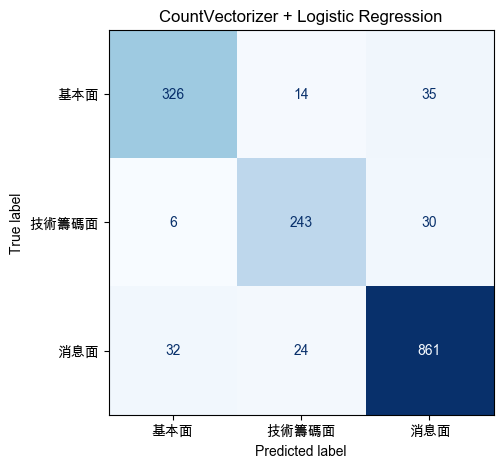

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_count, ax=ax, cmap="Blues", colorbar=False)
ax.set_title("CountVectorizer + Logistic Regression")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

### 3.4 TF-IDF

In [ ]:
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
vec_train = vectorizer.fit_transform(X_train)
vec_test = vectorizer.transform(X_test)

logistic_clf = LogisticRegression(max_iter=1000)
logistic_clf.fit(vec_train, y_train)
y_pred_tfidf = logistic_clf.predict(vec_test)

print(classification_report(y_test, y_pred_tfidf))

              precision    recall  f1-score   support

         基本面       0.93      0.84      0.88       375
       技術籌碼面       0.92      0.82      0.87       279
         消息面       0.91      0.97      0.94       917

    accuracy                           0.91      1571
   macro avg       0.92      0.88      0.90      1571
weighted avg       0.91      0.91      0.91      1571



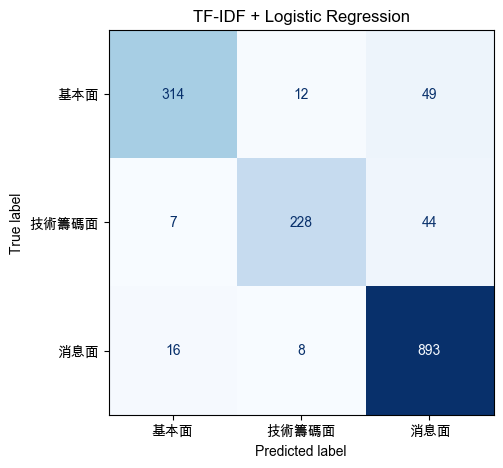

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tfidf, ax=ax, cmap="Blues", colorbar=False)
ax.set_title("TF-IDF + Logistic Regression")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

### 3.5 CV

為使模型評估更具穩定性，本研究進一步採用交叉驗證（cross-validation）檢視模型在訓練資料上的表現。


In [ ]:
clf = LogisticRegression(max_iter=1000)
vec_train_cv = TfidfVectorizer(max_features=1000, ngram_range=(1, 2)).fit_transform(X_train)

scores = cross_validate(
    clf,
    vec_train_cv,
    y_train,
    cv=5,
    scoring=("f1_macro", "recall_macro", "precision_macro"),
    return_estimator=True,
)
pprint(scores)

{'estimator': [LogisticRegression(max_iter=1000),
               LogisticRegression(max_iter=1000),
               LogisticRegression(max_iter=1000),
               LogisticRegression(max_iter=1000),
               LogisticRegression(max_iter=1000)],
 'fit_time': array([0.04302692, 0.03608084, 0.03499198, 0.05159283, 0.03632784]),
 'score_time': array([0.00660396, 0.00454402, 0.0042479 , 0.00432801, 0.00463891]),
 'test_f1_macro': array([0.92066362, 0.90211619, 0.90567619, 0.9137685 , 0.91157749]),
 'test_precision_macro': array([0.94074316, 0.92703608, 0.93028552, 0.94876853, 0.93112543]),
 'test_recall_macro': array([0.9038061 , 0.88278046, 0.88581117, 0.88835952, 0.89512535])}


`cross_val_predict()` 會回傳每筆訓練資料在交叉驗證下的預測類別，可用以觀察整體 CV 分類表現。


In [ ]:
y_pred_cv = cross_val_predict(clf, vec_train_cv, y_train, cv=5)
print(classification_report(y_train, y_pred_cv))

              precision    recall  f1-score   support

         基本面       0.96      0.87      0.91       876
       技術籌碼面       0.94      0.83      0.88       649
         消息面       0.91      0.98      0.95      2139

    accuracy                           0.93      3664
   macro avg       0.94      0.89      0.91      3664
weighted avg       0.93      0.93      0.92      3664



## 4. 比較不同模型效果

In [ ]:
def train_cv(vectorizer, clf, X, y):
    pipe = Pipeline([
        ("vectorizer", vectorizer),
        ("clf", clf),
    ])

    y_pred = cross_val_predict(pipe, X, y, cv=5)
    cls_report = classification_report(y, y_pred, output_dict=True)
    print(classification_report(y, y_pred))

    fitted_pipe = clone(pipe)
    fitted_pipe.fit(X, y)
    return cls_report, fitted_pipe

In [ ]:
X = data["words"]
y = data["facet_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777, stratify=y
)

model_set = {
    "clf_logistic": LogisticRegression(max_iter=1000),
    "clf_dtree": DecisionTreeClassifier(random_state=777),
    "clf_svc": LinearSVC(),
    "clf_rf": RandomForestClassifier(random_state=777, n_estimators=200),
}

result_set = {}
fitted_model_set = {}

for name, model in model_set.items():
    print("=" * 100)
    print(f"now training: {name}")
    result, fitted_pipe = train_cv(TfidfVectorizer(max_features=1000, ngram_range=(1, 2)), model, X_train, y_train)
    result_set[name] = result
    fitted_model_set[name] = fitted_pipe
    print("=" * 100)

now training: clf_logistic


              precision    recall  f1-score   support

         基本面       0.96      0.86      0.91       876
       技術籌碼面       0.94      0.82      0.88       649
         消息面       0.91      0.98      0.94      2139

    accuracy                           0.92      3664
   macro avg       0.93      0.89      0.91      3664
weighted avg       0.93      0.92      0.92      3664



now training: clf_dtree


              precision    recall  f1-score   support

         基本面       0.85      0.84      0.84       876
       技術籌碼面       0.78      0.80      0.79       649
         消息面       0.90      0.90      0.90      2139

    accuracy                           0.87      3664
   macro avg       0.84      0.85      0.84      3664
weighted avg       0.87      0.87      0.87      3664



now training: clf_svc


              precision    recall  f1-score   support

         基本面       0.93      0.88      0.90       876
       技術籌碼面       0.92      0.85      0.88       649
         消息面       0.93      0.97      0.95      2139

    accuracy                           0.93      3664
   macro avg       0.93      0.90      0.91      3664
weighted avg       0.93      0.93      0.93      3664



now training: clf_rf


              precision    recall  f1-score   support

         基本面       0.95      0.89      0.92       876
       技術籌碼面       0.94      0.85      0.89       649
         消息面       0.93      0.98      0.95      2139

    accuracy                           0.93      3664
   macro avg       0.94      0.91      0.92      3664
weighted avg       0.93      0.93      0.93      3664



In [ ]:
pd.DataFrame(
    {
        name: {
            "accuracy": report["accuracy"],
            "macro_f1": report["macro avg"]["f1-score"],
            "weighted_f1": report["weighted avg"]["f1-score"],
        }
        for name, report in result_set.items()
    }
).T.sort_values("macro_f1", ascending=False)

,accuracy,macro_f1,weighted_f1
clf_rf,0.934225,0.921179,0.933466
clf_svc,0.926310,0.910975,0.925537
clf_logistic,0.924672,0.909197,0.923501
clf_dtree,0.867631,0.844757,0.867893


In [ ]:
best_model_name = ""
best_model_metric = "f1-score"
max_score = 0

for name, report in result_set.items():
    if report["weighted avg"][best_model_metric] > max_score:
        max_score = report["weighted avg"][best_model_metric]
        best_model_name = name

print(f"best model: {best_model_name}")
pprint(result_set[best_model_name])

best model: clf_rf
{'accuracy': 0.9342248908296943,
 'macro avg': {'f1-score': 0.9211787213241779,
               'precision': 0.9393303963811478,
               'recall': 0.9057205895848166,
               'support': 3664.0},
 'weighted avg': {'f1-score': 0.9334659084062009,
                  'precision': 0.9348485567868943,
                  'recall': 0.9342248908296943,
                  'support': 3664.0},
 '基本面': {'f1-score': 0.9185360094451004,
         'precision': 0.9511002444987775,
         'recall': 0.8881278538812786,
         'support': 876.0},
 '技術籌碼面': {'f1-score': 0.8932038834951457,
           'precision': 0.9403747870528109,
           'recall': 0.8505392912172574,
           'support': 649.0},
 '消息面': {'f1-score': 0.9517962710322874,
         'precision': 0.9265161575918548,
         'recall': 0.978494623655914,
         'support': 2139.0}}


In [ ]:
best_pipe = fitted_model_set[best_model_name]
y_pred_best = best_pipe.predict(X_test)
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

         基本面       0.93      0.86      0.89       375
       技術籌碼面       0.97      0.84      0.90       279
         消息面       0.91      0.97      0.94       917

    accuracy                           0.92      1571
   macro avg       0.93      0.89      0.91      1571
weighted avg       0.92      0.92      0.92      1571



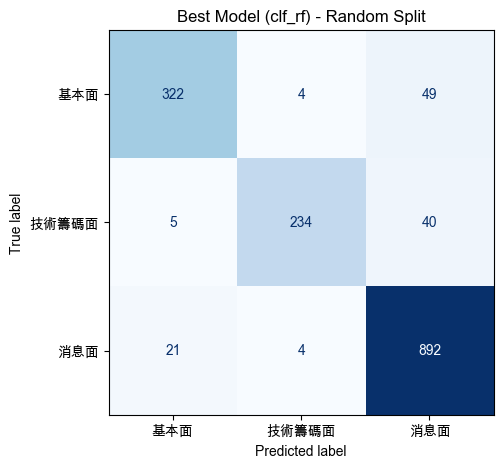

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Best Model ({best_model_name}) - Random Split")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()


由上述 confusion matrix 可觀察到，`消息面` 為最穩定之類別，多數文章可被正確辨識；隨機切分下共有 `892` 篇 `消息面` 文章被正確分類。

相較之下，`基本面` 與 `技術籌碼面` 較容易與 `消息面` 混淆：`基本面` 有 `49` 篇被誤分為 `消息面`，`技術籌碼面` 亦有 `40` 篇被誤分為 `消息面`。此結果顯示，PTT 股板文章中常出現「新聞事件帶出財務數字」或「消息敘事夾帶操作判斷」的情形，使 `消息面` 與另外兩類之邊界相對接近。

另一方面，`基本面` 與 `技術籌碼面` 彼此直接混淆的數量較少（僅 `4` 至 `5` 篇），表示本文的三分類設計下，財務營運訊號與籌碼／操作訊號仍具有一定區辨力。


### 4.1 補充：時間切分版本

除隨機切分外，本研究另進行一組較接近真實情境的時間切分：

- 訓練集：`2026-01-01` 至 `2026-03-31`
- 測試集：`2026-04-01` 至 `2026-04-15`

此設計可用以觀察模型是否能利用前幾個月的文章，預測後續新出現文章的面向。


In [ ]:
time_train = ptt_df[ptt_df["post_datetime"] < "2026-04-01"].copy()
time_test = ptt_df[ptt_df["post_datetime"] >= "2026-04-01"].copy()

X_train_time = time_train["words"]
y_train_time = time_train["facet_label"]
X_test_time = time_test["words"]
y_test_time = time_test["facet_label"]

print(f"time-train rows: {len(time_train)}")
print(y_train_time.value_counts())
print()
print(f"time-test rows: {len(time_test)}")
print(y_test_time.value_counts())


time-train rows: 4352
facet_label
消息面      2504
基本面      1040
技術籌碼面     808
Name: count, dtype: int64

time-test rows: 883
facet_label
消息面      552
基本面      211
技術籌碼面    120
Name: count, dtype: int64


In [ ]:
time_result_set = {}
time_fitted_model_set = {}

for name, model in model_set.items():
    print("=" * 100)
    print(f"now training (time split): {name}")
    pipe = Pipeline([
        ("vectorizer", TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
        ("clf", clone(model)),
    ])
    pipe.fit(X_train_time, y_train_time)
    y_pred = pipe.predict(X_test_time)
    report = classification_report(y_test_time, y_pred, output_dict=True)
    print(classification_report(y_test_time, y_pred))
    time_result_set[name] = report
    time_fitted_model_set[name] = pipe
    print("=" * 100)


now training (time split): clf_logistic


              precision    recall  f1-score   support

         基本面       0.96      0.89      0.92       211
       技術籌碼面       0.89      0.84      0.87       120
         消息面       0.94      0.98      0.96       552

    accuracy                           0.94       883
   macro avg       0.93      0.90      0.92       883
weighted avg       0.94      0.94      0.94       883

now training (time split): clf_dtree


              precision    recall  f1-score   support

         基本面       0.85      0.86      0.86       211
       技術籌碼面       0.75      0.87      0.81       120
         消息面       0.93      0.90      0.92       552

    accuracy                           0.89       883
   macro avg       0.85      0.87      0.86       883
weighted avg       0.89      0.89      0.89       883

now training (time split): clf_svc


              precision    recall  f1-score   support

         基本面       0.96      0.90      0.93       211
       技術籌碼面       0.89      0.84      0.86       120
         消息面       0.94      0.98      0.96       552

    accuracy                           0.94       883
   macro avg       0.93      0.91      0.92       883
weighted avg       0.94      0.94      0.94       883

now training (time split): clf_rf


              precision    recall  f1-score   support

         基本面       0.96      0.90      0.93       211
       技術籌碼面       0.90      0.87      0.88       120
         消息面       0.94      0.97      0.96       552

    accuracy                           0.94       883
   macro avg       0.93      0.91      0.92       883
weighted avg       0.94      0.94      0.94       883



In [ ]:
pd.DataFrame(
    {
        name: {
            "accuracy": report["accuracy"],
            "macro_f1": report["macro avg"]["f1-score"],
            "weighted_f1": report["weighted avg"]["f1-score"],
        }
        for name, report in time_result_set.items()
    }
).T.sort_values("macro_f1", ascending=False)


,accuracy,macro_f1,weighted_f1
clf_rf,0.941110,0.922276,0.940676
clf_svc,0.939977,0.917424,0.939422
clf_logistic,0.938845,0.916644,0.938179
clf_dtree,0.885617,0.859374,0.886772


In [ ]:
best_time_model_name = ""
best_time_score = 0

for name, report in time_result_set.items():
    if report["weighted avg"]["f1-score"] > best_time_score:
        best_time_score = report["weighted avg"]["f1-score"]
        best_time_model_name = name

print(f"best time-split model: {best_time_model_name}")
pprint(time_result_set[best_time_model_name])


best time-split model: clf_rf
{'accuracy': 0.9411098527746319,
 'macro avg': {'f1-score': 0.9222761009899595,
               'precision': 0.9332674120683002,
               'recall': 0.9123463149941617,
               'support': 883.0},
 'weighted avg': {'f1-score': 0.9406760927964588,
                  'precision': 0.9411417953494445,
                  'recall': 0.9411098527746319,
                  'support': 883.0},
 '基本面': {'f1-score': 0.9264705882352942,
         'precision': 0.9593908629441624,
         'recall': 0.8957345971563981,
         'support': 211.0},
 '技術籌碼面': {'f1-score': 0.8813559322033898,
           'precision': 0.896551724137931,
           'recall': 0.8666666666666667,
           'support': 120.0},
 '消息面': {'f1-score': 0.9590017825311943,
         'precision': 0.9438596491228071,
         'recall': 0.9746376811594203,
         'support': 552.0}}


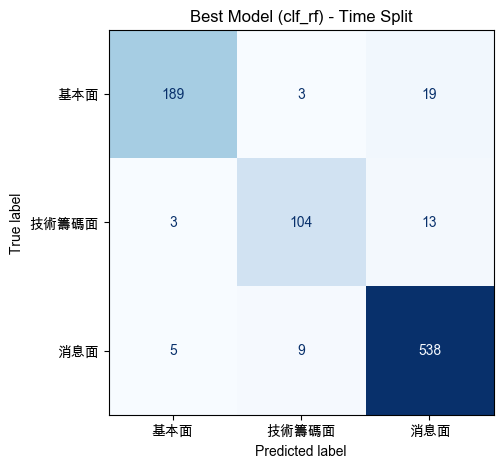

In [ ]:
best_time_pipe = time_fitted_model_set[best_time_model_name]
y_pred_best_time = best_time_pipe.predict(X_test_time)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_time, y_pred_best_time, ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Best Model ({best_time_model_name}) - Time Split")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()


時間切分版本的 confusion matrix 顯示，模型在 `2026-04-01` 至 `2026-04-15` 的新文章上仍維持穩定表現。`消息面` 共有 `538` 篇被正確辨識，僅少量誤分為 `基本面` (`5` 篇) 或 `技術籌碼面` (`9` 篇)。

`基本面` 與 `技術籌碼面` 仍是較容易出現誤判的兩類，其中 `基本面` 有 `19` 篇被分到 `消息面`，`技術籌碼面` 有 `13` 篇被分到 `消息面`。然而，與隨機切分相比，時間切分下的誤分類量並未明顯惡化，表示本文所設定的面向標籤與文本特徵在不同月份之間具有一定穩定性。

整體而言，confusion matrix 所反映的主要困難並非「基本面」與「技術籌碼面」彼此無法區分，而是部分文章本身同時含有事件描述與分析評論，因而更容易被吸收到 `消息面`。


## 5. 分析可解釋模型的結果

本節以 `TF-IDF + Logistic Regression` 為例，觀察哪些字詞對不同面向具有較高的區辨力。值得注意的是，前處理階段已先移除 `原文標題`、`原文連結`、`發布時間`、`記者署名` 等新聞模板欄位，以降低模型對轉貼格式的依賴。


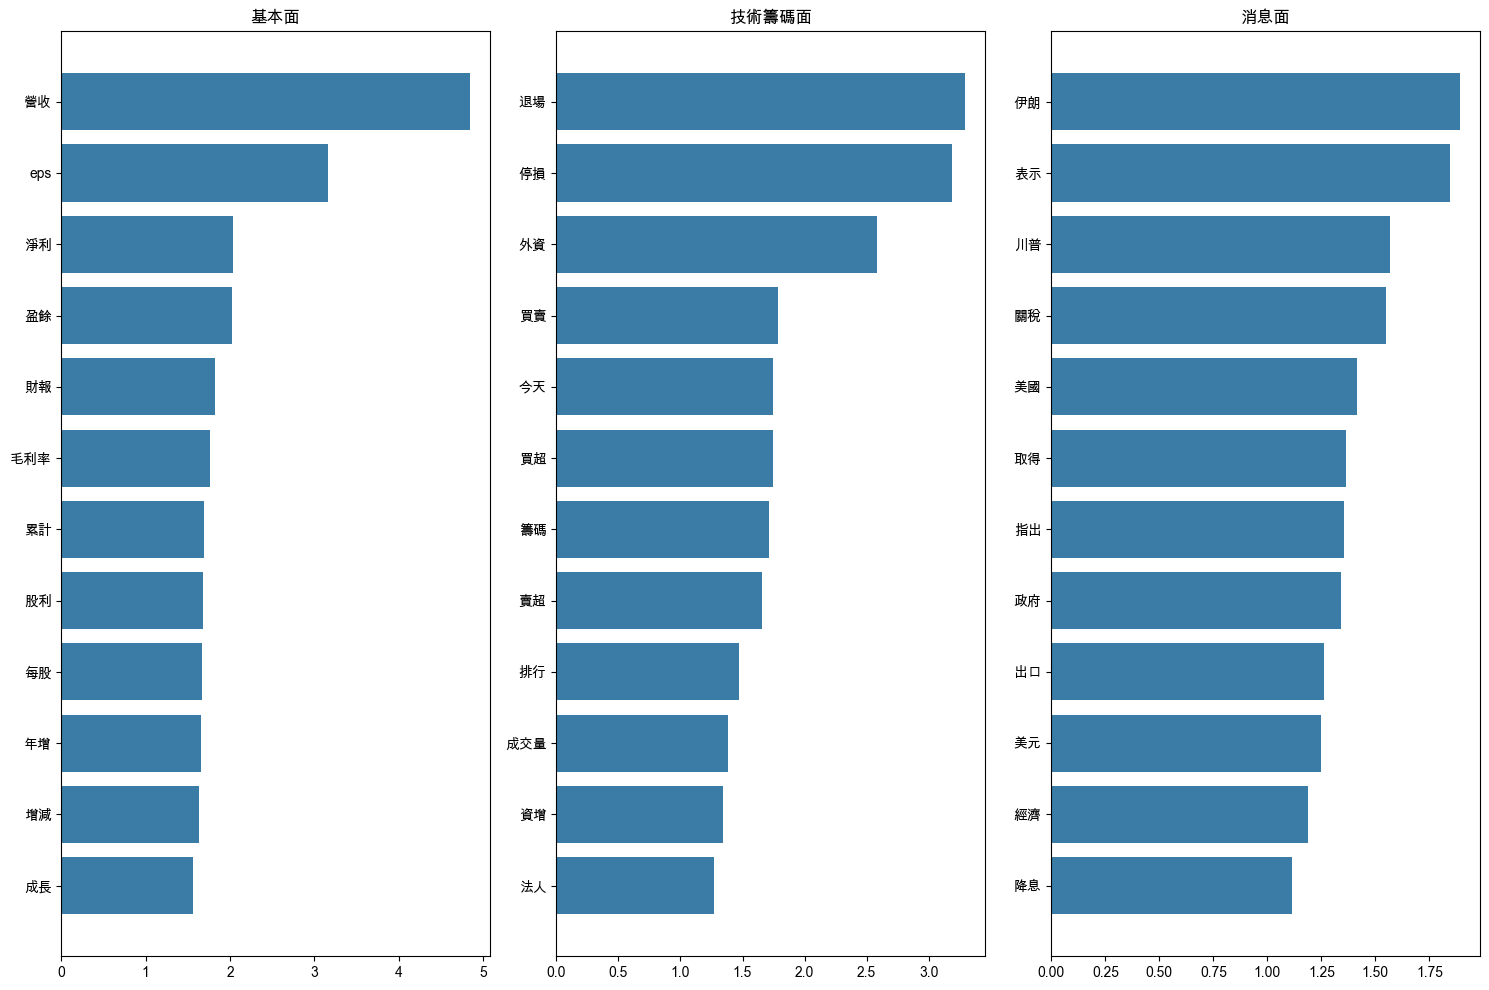

In [ ]:
def plot_coef(logistic_reg_model, feature_names, top_n=10):
    coef_df = pd.DataFrame(
        logistic_reg_model.coef_.T,
        columns=logistic_reg_model.classes_,
        index=feature_names,
    )
    fig, axes = plt.subplots(1, len(coef_df.columns), figsize=(15, 10))
    for ax, label in zip(axes, coef_df.columns):
        select_words = coef_df[label].sort_values(ascending=False).head(top_n)
        ax.barh(select_words.index[::-1], select_words.values[::-1], color="#3A7CA5")
        ax.set_title(label)
        ax.tick_params(axis="y", labelsize=10)
    plt.tight_layout()

plot_coef(logistic_clf, vectorizer.get_feature_names_out(), top_n=12)

### 5.1 各類別 top 20 關鍵詞表格

除係數長條圖外，下表進一步列出 `TF-IDF + Logistic Regression` 對三個面向判斷時最具代表性的前 20 個字詞及其係數，以便對照各類別的重要特徵。


In [ ]:
def build_top_keyword_table(logistic_reg_model, feature_names, top_n=20):
    coef_df = pd.DataFrame(
        logistic_reg_model.coef_.T,
        columns=logistic_reg_model.classes_,
        index=feature_names,
    )
    table = pd.DataFrame({"rank": range(1, top_n + 1)})
    for label in logistic_reg_model.classes_:
        select_words = coef_df[label].sort_values(ascending=False).head(top_n)
        table[f"{label}_keyword"] = select_words.index.tolist()
        table[f"{label}_coef"] = select_words.values.round(4)
    return table

top20_keywords = build_top_keyword_table(logistic_clf, vectorizer.get_feature_names_out(), top_n=20)
display(top20_keywords)


,rank,基本面_keyword,基本面_coef,技術籌碼面_keyword,技術籌碼面_coef,消息面_keyword,消息面_coef
0,1,營收,4.8418,退場,3.2892,伊朗,1.8896
1,2,eps,3.1590,停損,3.1883,表示,1.8453
2,3,淨利,2.0360,外資,2.5822,川普,1.5652
3,4,盈餘,2.0296,買賣,1.7854,關稅,1.5504
4,5,財報,1.8235,今天,1.7492,美國,1.4164
5,6,毛利率,1.7594,買超,1.7460,取得,1.3653
6,7,累計,1.6884,籌碼,1.7110,指出,1.3565
7,8,股利,1.6818,賣超,1.6607,政府,1.3405
8,9,每股,1.6685,排行,1.4683,出口,1.2604
9,10,年增,1.6505,成交量,1.3824,美元,1.2494


## 6. 用訓練好的分類器來觀察這段時間的文章面向

在完成模型訓練後，本文進一步利用表現最佳之分類器觀察整段期間的文章面向分布，以回應「該時段 PTT Stock 板主要以何種面向討論市場」此一問題。


agreement with rule labels: 0.9765


,count
facet_label,
消息面,3120
基本面,1224
技術籌碼面,891


pred_facet,基本面,技術籌碼面,消息面
post_datetime,,,
2026-01,322,302,805
2026-02,295,178,695
2026-03,400,293,1062
2026-04,207,118,558


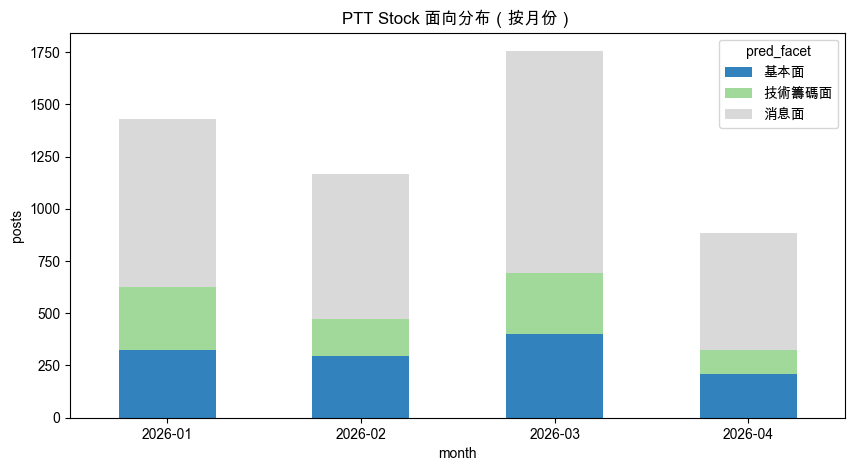

In [ ]:
ptt_df["pred_facet"] = best_pipe.predict(ptt_df["words"])
print(f"agreement with rule labels: {(ptt_df["pred_facet"] == ptt_df["facet_label"]).mean():.4f}")

facet_counts = ptt_df["pred_facet"].value_counts().rename_axis("facet_label").to_frame("count")
display(facet_counts)

monthly_counts = pd.crosstab(ptt_df["post_datetime"].dt.to_period("M").astype(str), ptt_df["pred_facet"])
display(monthly_counts)

ax = monthly_counts.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="tab20c")
ax.set_title("PTT Stock 面向分布（按月份）")
ax.set_xlabel("month")
ax.set_ylabel("posts")
plt.xticks(rotation=0)
plt.show()


## 作業結論

- 本研究先以規則式方法建立 `消息面`、`基本面`、`技術籌碼面` 三類標籤。
- 規則設計僅保留內容面向詞，不將 `原文連結 / 發布時間 / 記者署名` 等新聞模板字樣計入 `消息面`；此外，前處理階段亦會將此類模板欄位自文本中移除。
- 為降低過泛詞與貼文格式造成的誤判，除排除 `獲利 / 庫存 / 持股 / 突破 / 進場` 等容易誤傷的詞彙外，亦不將 `標的 / 分類 / 正文 / 機制 / 心得 / 評論 / 記者 / 分析 / 討論 / 報導 / 快訊` 等較偏向文章形式或署名的字詞納入模型特徵。
- 在評估設計上，同時保留 `隨機切分` 與 `時間切分` 兩種方式：前者用以對齊課堂 notebook，後者用以模擬以前期文章預測後續新文章之情境。
- 最後再以隨機切分下表現最佳的模型，觀察整段期間的文章面向分布。

### 本地執行摘要
- 作業版資料筆數：`5235`
- 規則式標籤分布：`消息面 3056`、`基本面 1251`、`技術籌碼面 928`
- 隨機切分（7:3）最佳模型為 `TF-IDF + RandomForest`，holdout test 約為：`accuracy 0.92`、`macro F1 0.91`
- 時間切分（1-3 月訓練、4 月測試）最佳模型為 `TF-IDF + RandomForest`，test 約為：`accuracy 0.94`、`macro F1 0.92`
- 隨機切分最佳模型對整批資料的預測與規則式標籤一致率約為 `0.9765`


## 第九週：主題模型（中文） <br>

本週課程為 **主題模型** ，學習如何將文本進行主題模型分析。<br>
文件主題模型採用非監督式學習的方式，不事先人為做標籤與註解，訓練的資料是從資料文本得來，讓我們可以規模化給予大量文本，而訓練出主題模型，其中最為知名為LDA模型，也是本次課程主要的教學目標，本 jupyter notebook 是以中文文本為示範。<br>
這次課程分為幾個部分：
1. 將資料進行前處理
2. Lexicon-based 的主題模型
3. LDA 主題模型
4. 視覺化主題模型
5. Seeded LDA (以權重引導的主題模型)
6. Guided LDA
7. 主題模型的應用


In [ ]:
import pandas as pd
import ast

# 讀取 PTT ETF 資料集
ptt_df = pd.read_csv('./raw_data/ptt_etf_articles.csv')

# 統一欄位名稱與格式以相容後續程式碼
ptt_df['artDate'] = pd.to_datetime(ptt_df['artDate'])
ptt_df['content'] = ptt_df['content_clean']

# 將字串格式的 tokens 轉換回 list 格式
def safe_eval(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else x
    except:
        return x

ptt_df['words'] = ptt_df['tokens'].apply(safe_eval)

# 建立 udn 變數供後續使用
udn = ptt_df.loc[:, ["content", "url", "artDate", "words"]]
udn['artCatagory'] = 'ETF'

print("資料載入完成，udn 變數已建立。")
display(udn.head(3))

資料載入完成，udn 變數已建立。


,content,url,artDate,words,artCatagory
0,0050 資產 規模 突破 億元 經理費率 降至 以下 中央社 記者 曾仁凱 台北 日電 主...,https://www.ptt.cc/bbs/Fund/M.1759405590.A.135...,2025-10-02,"[0050, 資產, 規模, 突破, 億元, 經理費率, 降至, 以下, 中央社, 記者, ...",ETF
1,富人 檔主動 ETF 狂飆 成勝 0050 達人 超額 報酬 關鍵 潛藏 大風險 旺得 富理...,https://www.ptt.cc/bbs/Fund/M.1756466227.A.F8D...,2025-08-29,"[富人, 檔主動, ETF, 狂飆, 成勝, 0050, 達人, 超額, 報酬, 關鍵, 潛...",ETF
2,最近 0050 連結 基金 轉倉 0050 etf 一下 國內 基金 贖回 假設 萬元 連結...,https://www.ptt.cc/bbs/Fund/M.1747840467.A.6B7...,2025-05-21,"[最近, 0050, 連結, 基金, 轉倉, 0050, etf, 一下, 國內, 基金, ...",ETF


In [ ]:
!pip install gensim
!pip install pyLDAvis
import time
from functools import reduce
from collections import Counter
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from gensim.models.ldamulticore import LdaMulticore
from gensim.matutils import corpus2csc, corpus2dense, Sparse2Corpus

import pyLDAvis
import pyLDAvis.gensim_models

c:\Anaconda\envs\social\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

In [ ]:
import warnings
# 忽略過時的警告訊息，讓輸出畫面更乾淨
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
# 安裝中文字體並設定隱藏警告
!apt-get -qq install -y fonts-noto-cjk

import matplotlib as mpl
import matplotlib.pyplot as plt
import logging

# 隱藏 matplotlib 的字體搜尋警告
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 設定 matplotlib 使用 Noto Sans CJK JP 字體
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


'apt-get' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# 設定中文字體
plt.rcParams['font.sans-serif'] = ['Arial Unicode Ms'] #使圖中中文能正常顯示
plt.rcParams['axes.unicode_minus'] = False #使負號能夠顯示

## 2. Lexicon-based / 人工給定主題的主題模型

In [ ]:
# 檢查資料集中的分類，現在應該只有 ETF
print(udn['artCatagory'].unique())

['ETF']


In [ ]:
# 若尚未執行到後面定義 custom_topic_word 的 cell，先提供預設值避免 NameError
if 'custom_topic_word' not in globals():
	custom_topic_word = {
		"高股息": ["配息", "股息", "高股息", "殖利率", "00878", "0056", "00919", "00929", "填息", "年化", "除息", "每月"]
	}

# 統計「高股息」主題相關詞彙出現頻率作為示範
dividend_cnt = udn.loc[udn['artCatagory'] == 'ETF', :]['words'].explode().value_counts()
# 篩選我們定義的關鍵字看看分佈
print("高股息相關關鍵字統計:")
print(dividend_cnt[dividend_cnt.index.isin(custom_topic_word['高股息'])].head(10))

高股息相關關鍵字統計:
words
0056    24
配息      16
高股息     12
除息       8
每月       6
股息       5
年化       3
填息       2
Name: count, dtype: int64


In [ ]:
stock_cnt = udn.loc[udn['artCatagory'] == '股市',:]['words'].explode().value_counts().head(200)
pprint(" ".join(stock_cnt.index))

''


In [ ]:
global_cnt = udn.loc[udn['artCatagory'] == '全球',:]['words'].explode().value_counts().head(200)
pprint(" ".join(global_cnt.index))

''


In [ ]:
# 針對 ETF 資料集重新定義人工主題關鍵詞
custom_topic_word = {
    "高股息": [
        "配息", "股息", "高股息", "殖利率", "00878", "0056", "00919", "00929", "填息", "年化", "除息", "每月"
    ],
    "市值型": [
        "0050", "006208", "權值股", "台積電", "大盤", "指數", "市值", "連動", "追蹤", "績效", "成長"
    ],
    "債券/利率": [
        "美債", "債券", "降息", "升息", "利率", "公債", "聯準會", "TLT", "投資級", "溢價", "長債"
    ],
    "市場情緒": [
        "韭菜", "套牢", "崩盤", "抄底", "畢業", "看多", "看空", "存股", "投資", "進場", "獲利"
    ]
}

從 `custom_topic_word` 的所有值中，整理出不重複的詞彙（vocabularies），並以 NumPy 陣列的形式儲存。

In [ ]:
vocabularies = np.unique(reduce(lambda x, y: x + y, custom_topic_word.values()))

In [ ]:
vocabularies

array(['0050', '0056', '006208', '00878', '00919', '00929', 'TLT', '債券',
       '公債', '利率', '升息', '台積電', '填息', '大盤', '套牢', '存股', '崩盤', '市值', '年化',
       '成長', '抄底', '投資', '投資級', '指數', '權值股', '殖利率', '每月', '溢價', '獲利',
       '畢業', '看多', '看空', '績效', '美債', '聯準會', '股息', '追蹤', '連動', '進場', '配息',
       '長債', '降息', '除息', '韭菜', '高股息'], dtype='<U6')

利用 `CountVectorizer` 的 `vocabulary` 參數來篩選、製作文件字詞矩陣 (DTM)。

In [ ]:
udn_corpus = udn['words'].map(" ".join)
vectorizer = CountVectorizer(vocabulary=vocabularies)
udn_matrix = vectorizer.fit_transform(udn_corpus)

udn_matrix = udn_matrix.toarray()
feature_names = vectorizer.get_feature_names_out()

DTM_df = pd.DataFrame(columns = feature_names, data = udn_matrix)
DTM_df

c:\Anaconda\envs\social\Lib\site-packages\sklearn\feature_extraction\text.py:1381: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(


,0050,0056,006208,00878,00919,00929,TLT,債券,公債,利率,...,股息,追蹤,連動,進場,配息,長債,降息,除息,韭菜,高股息
0,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,3,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,11,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,1,3,0,0,0,0,0,0,0,...,1,0,0,0,6,0,0,0,0,6


針對每個「自定義主題」，統計每篇文章在該主題下出現的詞彙總次數，整理成一個 DataFrame。

In [ ]:
df_count = pd.DataFrame({})

# k 是主題名稱，v 是這個主題下的詞彙list
for k, v in custom_topic_word.items():
    idx = np.isin(
        feature_names,
        v
    )
    df_count[f'topic_{k}'] = udn_matrix[:, idx].sum(axis=1)

df_count

,topic_高股息,topic_市值型,topic_債券/利率,topic_市場情緒
0,0,12,0,0
1,4,22,0,1
2,0,2,0,0
3,1,4,0,0
4,0,2,0,0
5,0,1,0,0
6,0,12,0,5
7,0,0,0,0
8,0,3,0,2
9,14,19,0,2


把每篇文章在各個主題的出現次數轉換成主題分佈機率（比例），也就是每篇文章屬於各個主題的相對權重 ($\\theta$ 向量)。

In [ ]:
thetas = df_count.div(
    df_count.sum(axis=1),
    axis=0
)
thetas.head()

,topic_高股息,topic_市值型,topic_債券/利率,topic_市場情緒
0,0.000000,1.000000,0.0,0.000000
1,0.148148,0.814815,0.0,0.037037
2,0.000000,1.000000,0.0,0.000000
3,0.200000,0.800000,0.0,0.000000
4,0.000000,1.000000,0.0,0.000000


## 3. LDA 主題模型
Latent Dirichlet allocation 簡稱 LDA，是一種主題模型，他可以將資料集中每篇文檔的主題按照機率分佈。他是無監督學習法，訓練時不需要手動標註，只需要給文檔集、主題數，也可以根據一些參數 ($\\alpha$、$\\beta$) 來改變模型訓練的結果。以下使用 `gensim` 套件來示範如何訓練 LDA 模型。

### 3.1 準備數據
將斷詞後的 `words` 轉換為 `gensim` 格式。

將斷詞後的`doc['words']`轉換成list

In [ ]:
docs = udn['words'].to_list()
docs[0]

['0050',
 '資產',
 '規模',
 '突破',
 '億元',
 '經理費率',
 '降至',
 '以下',
 '中央社',
 '記者',
 '曾仁凱',
 '台北',
 '日電',
 '主要',
 '上市',
 '股票',
 '市值',
 '元大台灣50',
 '0050',
 '今天',
 '收盤',
 '資產',
 '規模',
 '衝上',
 '台幣',
 '億元',
 '正式',
 '突破',
 '億元大關',
 '穩居',
 '台灣',
 'ETF',
 '龍頭',
 '照元大',
 '投信',
 '進費率',
 '公式',
 '0050',
 '最新',
 '經理費率',
 '受惠',
 '台股',
 '不斷',
 '新高',
 '尤其',
 '權值',
 '股領',
 '軍下',
 '0050',
 '今年',
 '以來',
 '資產',
 '規模',
 '成長',
 '快速',
 '月初',
 '億元大關',
 '不到',
 '今天',
 '創下',
 '億元',
 '里程碑',
 '分割',
 '以來',
 '波段',
 '漲幅',
 '元大',
 '投信',
 '今年初',
 '雙劍',
 '先大降',
 '0050',
 '用率',
 '之後進行',
 '分割',
 '成功',
 '吸引',
 '投資人',
 '湧入',
 '根據',
 '0050',
 '調降後的費',
 '用率',
 '規則',
 '依照',
 '基金',
 '規模',
 '採累',
 '進式',
 '調降',
 '基金',
 '規模',
 '台幣',
 '億元內',
 '部分',
 '經理費',
 '規模',
 '超過',
 '億元',
 '億元',
 '部分',
 '調整',
 '基金',
 '規模',
 '成長',
 '億元',
 '兆元',
 '部分',
 '調整',
 '超過',
 '兆元',
 '部分',
 '再調',
 '整為',
 '依照',
 '浮動',
 '計算',
 '方式',
 '隨著',
 '0050',
 '今天',
 '資產',
 '規模',
 '突破',
 '億元大關',
 '0050',
 '最新',
 '經理費率',
 '降到',
 '以下',
 '編輯',
 '張均',
 '0050',
 '突破',
 '億超',
 '費率'

建立並過濾詞彙表（Dictionary），只保留特定條件的詞彙，以減少雜訊。

In [ ]:
dictionary = Dictionary(docs)

dictionary.filter_extremes(no_below=5, no_above=0.99)
print(dictionary)

2026-04-27 22:24:24,111 : INFO : adding document #0 to Dictionary<0 unique tokens: []>
2026-04-27 22:24:24,113 : INFO : built Dictionary<2026 unique tokens: ['0050', 'ETF', '上市', '不到', '不斷']...> from 60 documents (total 6413 corpus positions)
2026-04-27 22:24:24,115 : INFO : Dictionary lifecycle event {'msg': "built Dictionary<2026 unique tokens: ['0050', 'ETF', '上市', '不到', '不斷']...> from 60 documents (total 6413 corpus positions)", 'datetime': '2026-04-27T22:24:24.115375', 'gensim': '4.3.3', 'python': '3.11.0 | packaged by Anaconda, Inc. | (main, Mar  1 2023, 18:18:21) [MSC v.1916 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'created'}
2026-04-27 22:24:24,116 : INFO : discarding 1869 tokens: [('不到', 3), ('不斷', 1), ('中央社', 1), ('主要', 3), ('之後進行', 1), ('今年初', 1), ('億元', 1), ('億元內', 1), ('億元大關', 1), ('億超', 1)]...
2026-04-27 22:24:24,116 : INFO : keeping 157 tokens which were in no less than 5 and no more than 59 (=99.0%) documents
2026-04-27 22:24:24,117 : INFO : r

Dictionary<157 unique tokens: ['0050', 'ETF', '上市', '今天', '今年']...>


參數說明：
- no_below=5	出現在少於 5 篇文章中的詞會被移除
- no_above=0.99	出現在超過 99% 文件中的詞會被移除

In [ ]:
for idx, (k, v) in enumerate(dictionary.token2id.items()):
    print(f"{k}: {v}")
    if idx > 10:
        break

0050: 0
ETF: 1
上市: 2
今天: 3
今年: 4
以下: 5
以來: 6
依照: 7
元大: 8
台灣: 9
台股: 10
基金: 11


將斷詞結果建構語料庫 (Corpus) 之後，利用語料庫把每篇文章數字化 (Bag-of-Words)。<br>
每個詞彙都被賦予一個 ID 及頻率 (word_id, word_frequency)。

In [ ]:
# 由於資料集大小不同，將原本的 iloc[600] 改為 iloc[0]
pprint(" ".join(udn['words'].iloc[0]))

('0050 資產 規模 突破 億元 經理費率 降至 以下 中央社 記者 曾仁凱 台北 日電 主要 上市 股票 市值 元大台灣50 0050 今天 收盤 '
 '資產 規模 衝上 台幣 億元 正式 突破 億元大關 穩居 台灣 ETF 龍頭 照元大 投信 進費率 公式 0050 最新 經理費率 受惠 台股 不斷 '
 '新高 尤其 權值 股領 軍下 0050 今年 以來 資產 規模 成長 快速 月初 億元大關 不到 今天 創下 億元 里程碑 分割 以來 波段 漲幅 元大 '
 '投信 今年初 雙劍 先大降 0050 用率 之後進行 分割 成功 吸引 投資人 湧入 根據 0050 調降後的費 用率 規則 依照 基金 規模 採累 '
 '進式 調降 基金 規模 台幣 億元內 部分 經理費 規模 超過 億元 億元 部分 調整 基金 規模 成長 億元 兆元 部分 調整 超過 兆元 部分 再調 '
 '整為 依照 浮動 計算 方式 隨著 0050 今天 資產 規模 突破 億元大關 0050 最新 經理費率 降到 以下 編輯 張均 0050 突破 億超 '
 '費率 降到 以下 投資人 賺到 持有 划算 ETF 霸主 地位 穩固 難撼動')


In [ ]:
# 同樣將索引改為 0 以符合資料集大小
dictionary.doc2bow(udn['words'].iloc[0])[:10]

[(0, 9),
 (1, 2),
 (2, 1),
 (3, 3),
 (4, 1),
 (5, 3),
 (6, 2),
 (7, 2),
 (8, 1),
 (9, 1)]

#### 將 docs 轉換成 BOW 形式
把每篇文件的 token list 轉換成一組 (token_id, count) 的 list。

In [ ]:
# 建立 Bag-of-words 作為文章的特徵表示
# 用 gensim ldamodel input 需要將文章轉換成 bag of words
corpus = [dictionary.doc2bow(doc) for doc in docs]

### 3.2 開始訓練 LDA topic model

+ 參數說明：
    + `corpus`: 文檔語料庫
    + `id2word`: 詞彙字典
    + `num_topics`: 生成幾個主題數
    + `random_state`: 固定亂數值，確保結果可重現
    + `passes`: 整個 corpus 訓練模型的次數

In [ ]:
ldamodel = LdaModel(
    corpus=corpus,
    id2word=dictionary, # 字典
    num_topics=10, # 生成幾個主題數
    random_state=2024, # 亂數
)

2026-04-27 22:24:32,065 : INFO : using symmetric alpha at 0.1
2026-04-27 22:24:32,065 : INFO : using symmetric eta at 0.1
2026-04-27 22:24:32,065 : INFO : using serial LDA version on this node
2026-04-27 22:24:32,074 : INFO : running online (single-pass) LDA training, 10 topics, 1 passes over the supplied corpus of 60 documents, updating model once every 60 documents, evaluating perplexity every 60 documents, iterating 50x with a convergence threshold of 0.001000
2026-04-27 22:24:32,074 : WARNING : too few updates, training might not converge; consider increasing the number of passes or iterations to improve accuracy
2026-04-27 22:24:32,094 : INFO : -6.267 per-word bound, 77.0 perplexity estimate based on a held-out corpus of 60 documents with 3046 words
2026-04-27 22:24:32,095 : INFO : PROGRESS: pass 0, at document #60/60
2026-04-27 22:24:32,112 : INFO : topic #9 (0.100): 0.302*"基金" + 0.070*"ETF" + 0.067*"0050" + 0.062*"台灣" + 0.024*"台股" + 0.023*"元大" + 0.013*"報酬" + 0.013*"高股息" + 0.013*

### 3.3 查看 LDA 主題代表字
當 LDA 模型訓練好之後，我們可以查看每個主題的單詞分佈。

In [ ]:
ldamodel.print_topics()

2026-04-27 22:24:34,271 : INFO : topic #0 (0.100): 0.088*"0050" + 0.065*"最近" + 0.059*"報酬" + 0.037*"0056" + 0.019*"十年" + 0.018*"ETF" + 0.018*"波動度" + 0.018*"小弟" + 0.017*"一年" + 0.017*"上市"
2026-04-27 22:24:34,271 : INFO : topic #1 (0.100): 0.096*"報酬" + 0.040*"最近" + 0.040*"策略" + 0.039*"槓桿" + 0.026*"台股" + 0.026*"期貨" + 0.023*"持有" + 0.020*"五年" + 0.020*"同期" + 0.020*"定值"
2026-04-27 22:24:34,272 : INFO : topic #2 (0.100): 0.087*"ETF" + 0.047*"台股" + 0.045*"基金" + 0.037*"指數" + 0.036*"投資" + 0.034*"0050" + 0.022*"槓桿" + 0.022*"比例" + 0.021*"市場" + 0.019*"報酬"
2026-04-27 22:24:34,273 : INFO : topic #3 (0.100): 0.056*"投資" + 0.052*"基金" + 0.039*"台灣50" + 0.039*"0050" + 0.032*"投入" + 0.031*"交易" + 0.031*"比例" + 0.028*"操作" + 0.022*"除息" + 0.021*"部位"
2026-04-27 22:24:34,273 : INFO : topic #4 (0.100): 0.071*"報酬" + 0.049*"最近" + 0.034*"槓桿" + 0.032*"投資" + 0.029*"期貨" + 0.028*"指數" + 0.027*"台股" + 0.027*"策略" + 0.026*"持有" + 0.022*"同期"
2026-04-27 22:24:34,273 : INFO : topic #5 (0.100): 0.076*"0050" + 0.051*"股價" + 0.036*"資料" + 

[(0,
  '0.088*"0050" + 0.065*"最近" + 0.059*"報酬" + 0.037*"0056" + 0.019*"十年" + 0.018*"ETF" + 0.018*"波動度" + 0.018*"小弟" + 0.017*"一年" + 0.017*"上市"'),
 (1,
  '0.096*"報酬" + 0.040*"最近" + 0.040*"策略" + 0.039*"槓桿" + 0.026*"台股" + 0.026*"期貨" + 0.023*"持有" + 0.020*"五年" + 0.020*"同期" + 0.020*"定值"'),
 (2,
  '0.087*"ETF" + 0.047*"台股" + 0.045*"基金" + 0.037*"指數" + 0.036*"投資" + 0.034*"0050" + 0.022*"槓桿" + 0.022*"比例" + 0.021*"市場" + 0.019*"報酬"'),
 (3,
  '0.056*"投資" + 0.052*"基金" + 0.039*"台灣50" + 0.039*"0050" + 0.032*"投入" + 0.031*"交易" + 0.031*"比例" + 0.028*"操作" + 0.022*"除息" + 0.021*"部位"'),
 (4,
  '0.071*"報酬" + 0.049*"最近" + 0.034*"槓桿" + 0.032*"投資" + 0.029*"期貨" + 0.028*"指數" + 0.027*"台股" + 0.027*"策略" + 0.026*"持有" + 0.022*"同期"'),
 (5,
  '0.076*"0050" + 0.051*"股價" + 0.036*"資料" + 0.036*"現金" + 0.033*"持有" + 0.031*"投資" + 0.024*"報酬" + 0.020*"今天" + 0.020*"槓桿" + 0.019*"買進"'),
 (6,
  '0.110*"基金" + 0.060*"報酬" + 0.024*"策略" + 0.022*"投入" + 0.020*"槓桿" + 0.019*"最近" + 0.019*"投資" + 0.017*"定期" + 0.016*"計算" + 0.016*"0050"'),
 (7,
  '0.

我們可以根據每個主題的詞彙分佈來猜測該主題可能是有關什麼樣的議題。在本 ETF 資料集中，可能會出現「高股息」、「市值型」、「債券」等主題。

也可以使用 `get_document_topics()` 回去看每篇文章的主題分佈 ($\\theta$)。

In [ ]:
ldamodel.get_document_topics(corpus[0])

[(9, 0.9799953)]

### 3.4 查看 LDA 模型指標
+ **Perplexity (困惑度)**: 指標越小越好，代表模型對文檔的預測能力越強。
+ **Coherence (一致性)**: 這裡使用 NPMI，數值通常在 [-1, 1] 之間，越大代表主題內的詞彙相關性越高。

In [ ]:
# perplexity
perplexity = ldamodel.log_perplexity(corpus)
perplexity

2026-04-27 22:24:37,743 : INFO : -4.742 per-word bound, 26.8 perplexity estimate based on a held-out corpus of 60 documents with 3046 words


-4.741518783671091

將對數困惑度 (log perplexity) 轉回原始的困惑度值。

In [ ]:
np.exp2(-perplexity)

26.750960426011943

In [ ]:
# npmi
NPMI_model_lda = CoherenceModel(model=ldamodel, texts=docs, coherence='c_npmi')
NPMI_lda = NPMI_model_lda.get_coherence()
print('這個主題模型的 PMI score: ', NPMI_lda)

2026-04-27 22:25:04,968 : INFO : using ParallelWordOccurrenceAccumulator<processes=15, batch_size=64> to estimate probabilities from sliding windows
2026-04-27 22:25:05,820 : INFO : 1 batches submitted to accumulate stats from 64 documents (5873 virtual)
2026-04-27 22:25:06,669 : INFO : 15 accumulators retrieved from output queue
2026-04-27 22:25:06,675 : INFO : accumulated word occurrence stats for 5873 virtual documents


這個主題模型的 PMI score:  -0.14158553521549794


也可以列出主題模型中，每個主題詞語之間的 PMI score。

In [ ]:
NPMI_model_lda.get_coherence_per_topic()

[-0.142730912846295,
 0.009283171526699994,
 -0.20843835806037045,
 -0.29752869025746154,
 -0.01059510211302091,
 -0.21368753838731017,
 -0.21337041872682067,
 0.10188803251945541,
 -0.17326722724735188,
 -0.26740830856250397]

`NPMI` 的值域是[-1,1]，-1 代表兩個字沒一起出現過，0 代表兩個字之間獨立，1 代表兩個字完全相關

### 3.5 透過指標找出最佳主題數
透過建立不同主題數的模型，並以困惑度與一致性指標來找出最佳的主題數。

In [ ]:
t0 = time.time()

topic_num_list = np.arange(2, 10)
result = {"topic_num":[], "perplexity":[], "pmi":[]}
model_set = dict()


for topic_num in topic_num_list:
    # perplexity
    model = LdaModel(
        corpus = corpus,
        num_topics = topic_num ,
        id2word=dictionary,
        random_state = 1500,
        passes=5 # 訓練次數
        )

    loss = model.log_perplexity(corpus)
    pmi = CoherenceModel(model=model, texts=docs, coherence='c_npmi').get_coherence()
    perplexity = np.exp(-1. * loss)

    # model_set[f'k_{topic_num}'] = model

    result['topic_num'].append(topic_num)
    result['perplexity'].append(perplexity)
    result['pmi'].append(pmi)

print(f"花費時間: {time.time() - t0} sec")


2026-04-27 22:25:20,110 : INFO : using symmetric alpha at 0.5
2026-04-27 22:25:20,110 : INFO : using symmetric eta at 0.5
2026-04-27 22:25:20,111 : INFO : using serial LDA version on this node
2026-04-27 22:25:20,112 : INFO : running online (multi-pass) LDA training, 2 topics, 5 passes over the supplied corpus of 60 documents, updating model once every 60 documents, evaluating perplexity every 60 documents, iterating 50x with a convergence threshold of 0.001000
2026-04-27 22:25:20,112 : WARNING : too few updates, training might not converge; consider increasing the number of passes or iterations to improve accuracy
2026-04-27 22:25:20,134 : INFO : -5.492 per-word bound, 45.0 perplexity estimate based on a held-out corpus of 60 documents with 3046 words
2026-04-27 22:25:20,135 : INFO : PROGRESS: pass 0, at document #60/60
2026-04-27 22:25:20,153 : INFO : topic #0 (0.500): 0.065*"報酬" + 0.035*"最近" + 0.032*"0050" + 0.028*"投資" + 0.027*"槓桿" + 0.025*"台股" + 0.023*"ETF" + 0.023*"策略" + 0.022*"指數

花費時間: 14.958101511001587 sec


訓練模型較花時間，此處我們嘗試不同的主題數量並記錄其指標變化。

In [ ]:
result = pd.DataFrame(result)
result

,topic_num,perplexity,pmi
0,2,94.904805,-0.090888
1,3,81.516136,-0.123676
2,4,82.265995,-0.125571
3,5,74.320947,-0.114585
4,6,77.696563,-0.142697
5,7,76.911520,-0.149315
6,8,87.051913,-0.219960
7,9,84.155473,-0.224581


<Axes: xlabel='topic_num'>

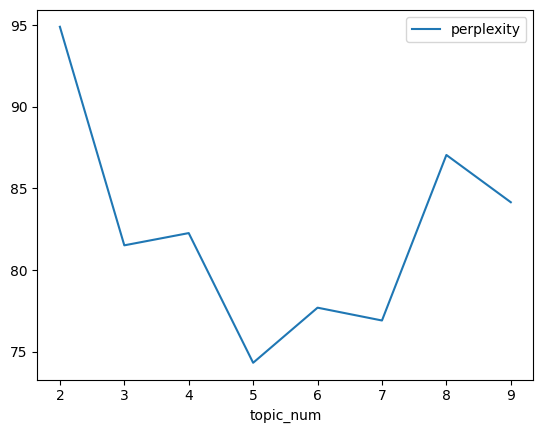

In [ ]:
result.plot.line(x='topic_num', y='perplexity')

<Axes: xlabel='topic_num'>

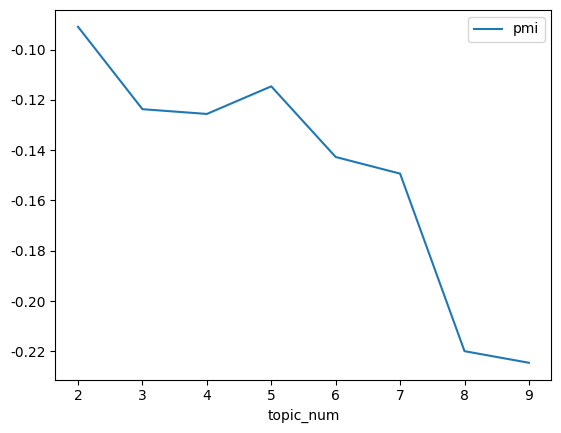

In [ ]:
result.plot.line(x='topic_num', y='pmi')

就訓練結果來看，我們可以觀察困惑度下降與一致性上升的轉折點來決定最終主題數。

## 4. 視覺化呈現
`pyLDAvis` 是常用的視覺化工具，幫助我們解釋主題模型中文件的主題分佈 ($\\theta$) 與主題的字分佈 ($\\phi$)。

In [ ]:
best_model = LdaModel(
    corpus = corpus,
    num_topics = 8,
    id2word=dictionary,
    random_state = 1500,
    passes = 5 # 訓練次數
    )

2026-04-27 22:25:48,511 : INFO : using symmetric alpha at 0.125
2026-04-27 22:25:48,512 : INFO : using symmetric eta at 0.125
2026-04-27 22:25:48,512 : INFO : using serial LDA version on this node
2026-04-27 22:25:48,512 : INFO : running online (multi-pass) LDA training, 8 topics, 5 passes over the supplied corpus of 60 documents, updating model once every 60 documents, evaluating perplexity every 60 documents, iterating 50x with a convergence threshold of 0.001000
2026-04-27 22:25:48,514 : WARNING : too few updates, training might not converge; consider increasing the number of passes or iterations to improve accuracy
2026-04-27 22:25:48,534 : INFO : -6.051 per-word bound, 66.3 perplexity estimate based on a held-out corpus of 60 documents with 3046 words
2026-04-27 22:25:48,535 : INFO : PROGRESS: pass 0, at document #60/60
2026-04-27 22:25:48,550 : INFO : topic #3 (0.125): 0.094*"0050" + 0.068*"基金" + 0.043*"股價" + 0.028*"投資" + 0.020*"資料" + 0.019*"現金" + 0.015*"這樣" + 0.015*"一張" + 0.014*

In [ ]:
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(best_model, corpus, dictionary, n_jobs=1)
p

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
7      0.248624 -0.108402       1        1  46.937961
6     -0.003607  0.139653       2        1  20.345664
2      0.000229  0.075390       3        1  13.818559
3     -0.055436 -0.078049       4        1   7.421504
0     -0.187451 -0.148526       5        1   4.816579
1     -0.033320  0.133696       6        1   4.651562
5      0.003148 -0.004350       7        1   1.774442
4      0.027813 -0.009412       8        1   0.233730, topic_info=    Term        Freq       Total Category  logprob  loglift
11    基金  189.000000  189.000000  Default  30.0000  30.0000
0   0050  128.000000  128.000000  Default  29.0000  29.0000
23    報酬  159.000000  159.000000  Default  28.0000  28.0000
97    小弟   35.000000   35.000000  Default  27.0000  27.0000
28    投資   70.000000   70.000000  Default  26.0000  26.0000
..   ...         ...         ...      ...      ...      ...
83    股價    0.051557   38.276134   Topic8  -4.9279  -0.5511
23    報酬    0.055547  159.598075   Topic8  -4.8533  -1.9044
0   0050    0.053886  128.472600   Topic8  -4.8837  -1.7178
28    投資    0.050678   70.188502   Topic8  -4.9451  -1.1747
94   之銘言    0.047949   29.848958   Topic8  -5.0004  -0.3750

[378 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
0         1  0.256864  0050
0         2  0.070054  0050
0         3  0.350269  0050
0         4  0.179027  0050
0         5  0.023351  0050
...     ...       ...   ...
153       4  0.115828    高手
153       5  0.231655    高手
55        2  0.669651   高股息
55        3  0.083706   高股息
55        6  0.083706   高股息

[488 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[8, 7, 3, 4, 1, 2, 6, 5])

如果主題之間重疊過多，可以嘗試調整主題數。以下我們根據視覺化結果進行調整。

In [ ]:
model_5 = LdaModel(
    corpus = corpus,
    num_topics = 5,
    id2word=dictionary,
    random_state = 1500,
    passes = 5 # 訓練次數
    )
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(model_5, corpus, dictionary, n_jobs=1)
p

2026-04-27 22:25:54,010 : INFO : using symmetric alpha at 0.2
2026-04-27 22:25:54,011 : INFO : using symmetric eta at 0.2
2026-04-27 22:25:54,011 : INFO : using serial LDA version on this node
2026-04-27 22:25:54,012 : INFO : running online (multi-pass) LDA training, 5 topics, 5 passes over the supplied corpus of 60 documents, updating model once every 60 documents, evaluating perplexity every 60 documents, iterating 50x with a convergence threshold of 0.001000
2026-04-27 22:25:54,012 : WARNING : too few updates, training might not converge; consider increasing the number of passes or iterations to improve accuracy
2026-04-27 22:25:54,030 : INFO : -5.807 per-word bound, 56.0 perplexity estimate based on a held-out corpus of 60 documents with 3046 words
2026-04-27 22:25:54,031 : INFO : PROGRESS: pass 0, at document #60/60
2026-04-27 22:25:54,046 : INFO : topic #0 (0.200): 0.086*"報酬" + 0.040*"最近" + 0.028*"策略" + 0.027*"槓桿" + 0.024*"台股" + 0.023*"投資" + 0.022*"持有" + 0.021*"買進" + 0.021*"期貨" +

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.067445 -0.113558       1        1  29.424580
0     -0.171913  0.023146       2        1  26.947233
4      0.223679  0.136892       3        1  15.814931
3     -0.169341  0.075873       4        1  15.722730
1      0.050130 -0.122352       5        1  12.090526, topic_info=   Term        Freq       Total Category  logprob  loglift
11   基金  201.000000  201.000000  Default  30.0000  30.0000
34   最近   98.000000   98.000000  Default  29.0000  29.0000
1   ETF   78.000000   78.000000  Default  28.0000  28.0000
9    台灣   44.000000   44.000000  Default  27.0000  27.0000
23   報酬  157.000000  157.000000  Default  26.0000  26.0000
..  ...         ...         ...      ...      ...      ...
99   引述    5.745350   29.181395   Topic5  -4.1604   0.4876
23   報酬    8.611064  157.380292   Topic5  -3.7558  -0.7929
15   方式    4.858178   27.903525   Topic5  -4.3282   0.3647
13   持有    4.654790   43.089594   Topic5  -4.3709  -0.1126
1   ETF    4.813714   78.055792   Topic5  -4.3374  -0.6732

[229 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
0         1  0.482054  0050
0         2  0.016068  0050
0         3  0.096411  0050
0         4  0.257095  0050
0         5  0.144616  0050
...     ...       ...   ...
153       1  0.698133    高手
153       5  0.116355    高手
55        1  0.399646   高股息
55        3  0.479575   高股息
55        5  0.079929   高股息

[413 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 1, 5, 4, 2])

替換主題數跑看看，可以看出最佳參數的數字和人類判斷的不一定會相符，逐步調整是很重要的。
lambda 的意義: <https://nlp.stanford.edu/events/illvi2014/papers/sievert-illvi2014.pdf>

## 5. GuidedLDA

- 原始套件: <https://github.com/vi3k6i5/GuidedLDA>  
- 31lab 家銘修改版本: <https://github.com/Text-Analytics-and-Retrieval/GuidedLDA>

安裝方式:  
`pip install git+https://github.com/Text-Analytics-and-Retrieval/GuidedLDA.git#egg=GuidedLDA`  
經測試，在 `python3.7~3.11.0` 可正常執行

In [ ]:
!pyenv install 3.11.0
!pyenv global 3.11.0

'pyenv' is not recognized as an internal or external command,
operable program or batch file.
'pyenv' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# 先看一下每个主题的关键词
import guidedlda

for topic_id, topic in seeded_lda.print_topics(num_topics=num_topics, num_words=10):
    print(f"Topic {topic_id}: {topic}")


2026-04-27 22:31:49,669 : INFO : topic #0 (0.167): 0.264*"0050" + 0.180*"指數" + 0.060*"最近" + 0.051*"報酬" + 0.019*"一年" + 0.019*"十年" + 0.017*"以來" + 0.017*"方式" + 0.017*"上市" + 0.016*"波動度"
2026-04-27 22:31:49,669 : INFO : topic #1 (0.167): 0.333*"0056" + 0.309*"高股息" + 0.309*"配息" + 0.001*"策略" + 0.001*"報酬" + 0.000*"槓桿" + 0.000*"一直" + 0.000*"並不" + 0.000*"最近" + 0.000*"像是"
2026-04-27 22:31:49,670 : INFO : topic #2 (0.167): 0.288*"基金" + 0.107*"ETF" + 0.062*"台灣" + 0.038*"台股" + 0.023*"0050" + 0.021*"績效" + 0.019*"元大" + 0.019*"投資" + 0.018*"市場" + 0.017*"指數"
2026-04-27 22:31:49,670 : INFO : topic #3 (0.167): 0.309*"獲利" + 0.039*"投資" + 0.037*"投入" + 0.028*"台灣50" + 0.026*"操作" + 0.025*"交易" + 0.021*"比例" + 0.018*"部位" + 0.015*"問題" + 0.014*"部分"
2026-04-27 22:31:49,670 : INFO : topic #4 (0.167): 0.128*"基金" + 0.073*"報酬" + 0.043*"槓桿" + 0.035*"最近" + 0.035*"策略" + 0.028*"期貨" + 0.027*"台股" + 0.026*"持有" + 0.020*"指數" + 0.020*"投資"
2026-04-27 22:31:49,671 : INFO : topic #5 (0.167): 0.064*"0050" + 0.058*"股價" + 0.057*"現金" + 0.

Topic 0: 0.264*"0050" + 0.180*"指數" + 0.060*"最近" + 0.051*"報酬" + 0.019*"一年" + 0.019*"十年" + 0.017*"以來" + 0.017*"方式" + 0.017*"上市" + 0.016*"波動度"
Topic 1: 0.333*"0056" + 0.309*"高股息" + 0.309*"配息" + 0.001*"策略" + 0.001*"報酬" + 0.000*"槓桿" + 0.000*"一直" + 0.000*"並不" + 0.000*"最近" + 0.000*"像是"
Topic 2: 0.288*"基金" + 0.107*"ETF" + 0.062*"台灣" + 0.038*"台股" + 0.023*"0050" + 0.021*"績效" + 0.019*"元大" + 0.019*"投資" + 0.018*"市場" + 0.017*"指數"
Topic 3: 0.309*"獲利" + 0.039*"投資" + 0.037*"投入" + 0.028*"台灣50" + 0.026*"操作" + 0.025*"交易" + 0.021*"比例" + 0.018*"部位" + 0.015*"問題" + 0.014*"部分"
Topic 4: 0.128*"基金" + 0.073*"報酬" + 0.043*"槓桿" + 0.035*"最近" + 0.035*"策略" + 0.028*"期貨" + 0.027*"台股" + 0.026*"持有" + 0.020*"指數" + 0.020*"投資"
Topic 5: 0.064*"0050" + 0.058*"股價" + 0.057*"現金" + 0.054*"一張" + 0.046*"參考" + 0.041*"投資" + 0.038*"報酬" + 0.037*"資料" + 0.030*"設定" + 0.029*"計算"


In [ ]:
# 再给每套种子词定个名字  稍微匹配展示一下
topic_dist = seeded_lda.get_document_topics(corpus)

main_topics = []
main_probs = []

for doc_topics in topic_dist:
    main_topic, main_prob = max(doc_topics, key=lambda x: x[1])
    main_topics.append(main_topic)
    main_probs.append(main_prob)

udn["seeded_topic"] = main_topics
udn["seeded_topic_prob"] = main_probs

topic_names = {
    0: "0050 / 台積電 / 市值型ETF",
    1: "配息 / 高股息ETF",
    2: "美債 / 利率 / 債券ETF",
    3: "套牢 / 抄底 / 存股操作",
    4: "基金 / 投信 / 費用規模",
    5: "一般ETF討論"
}

udn["seeded_topic_name"] = udn["seeded_topic"].map(topic_names)

udn[[
    "artDate",
    "content",
    "seeded_topic",
    "seeded_topic_name",
    "seeded_topic_prob"
]].head(10)

,artDate,content,seeded_topic,seeded_topic_name,seeded_topic_prob
0,2025-10-02,0050 資產 規模 突破 億元 經理費率 降至 以下 中央社 記者 曾仁凱 台北 日電 主...,2,美債 / 利率 / 債券ETF,0.357017
1,2025-08-29,富人 檔主動 ETF 狂飆 成勝 0050 達人 超額 報酬 關鍵 潛藏 大風險 旺得 富理...,2,美債 / 利率 / 債券ETF,0.896241
2,2025-05-21,最近 0050 連結 基金 轉倉 0050 etf 一下 國內 基金 贖回 假設 萬元 連結...,3,套牢 / 抄底 / 存股操作,0.375184
3,2024-09-05,本來 威良 先生 講得 還算 中肯 高股息 ETF 根本 垃圾 賠錢貨 聽到 出來 確貢獻 ...,0,0050 / 台積電 / 市值型ETF,0.675762
4,2024-05-22,昨天 台股 跌勢 剛好 一筆 資金 進來 0050 順便射 飛標 一些 ETF 包括 006...,2,美債 / 利率 / 債券ETF,0.463977
5,2024-05-13,三月份 0050 今天 五月 資金 暫時 賣出 這價還 OK 帳單,3,套牢 / 抄底 / 存股操作,0.663207
6,2023-05-03,原文 連結 內容 國民 ETF 元大台灣50 0050 成立 將滿 週年 規模 億為 最大 ...,2,美債 / 利率 / 債券ETF,0.525348
7,2021-11-21,本身 新手 想先 這兩筆 穩健 ETF 下手 推薦 哪種 方式 定期定額 單筆 買進 另外 ...,3,套牢 / 抄底 / 存股操作,0.915627
8,2021-09-03,以前 Richart 定期定額 0050 ETF 最近 投資 報酬 還滿 理想 另外 幾檔 ...,3,套牢 / 抄底 / 存股操作,0.552481
9,2021-02-14,本文 轉錄 Stock 1WAEZVk0 muzhu 蔡九 Stock 其他 台股 基金 E...,2,美債 / 利率 / 債券ETF,0.966878


In [ ]:
# GuidedLDA 需要 Dense DTM 格式（文件 x 詞彙）
X = corpus2dense(corpus, len(dictionary), len(corpus)).T.astype('int64')

# 訓練 GuidedLDA，主題數與種子主題數一致
guided_model = guidedlda.GuidedLDA(n_topics=5, n_iter=100, random_state=2024, refresh=20)
# 將 seed_topic_list 轉成 GuidedLDA 需要的 seed_topics 格式：{word_id: topic_id}
seeded_topics = {}
for topic_id, seed_words in enumerate(seed_topic_list):
    for w in seed_words:
        if w in word2id:
            seeded_topics[word2id[w]] = topic_id

guided_model.fit(X, seed_topics=seeded_topics, seed_confidence=0.8)

print("GuidedLDA 訓練完成")

2026-04-27 22:31:55,494 : INFO : n_documents: 60
2026-04-27 22:31:55,494 : INFO : vocab_size: 157
2026-04-27 22:31:55,495 : INFO : n_words: 3046
2026-04-27 22:31:55,496 : INFO : n_topics: 5
2026-04-27 22:31:55,496 : INFO : n_iter: 100
2026-04-27 22:31:55,501 : INFO : <0> log likelihood: -22205
2026-04-27 22:31:55,530 : INFO : <20> log likelihood: -14292
2026-04-27 22:31:55,560 : INFO : <40> log likelihood: -13987
2026-04-27 22:31:55,591 : INFO : <60> log likelihood: -13835
2026-04-27 22:31:55,621 : INFO : <80> log likelihood: -13769
2026-04-27 22:31:55,650 : INFO : <99> log likelihood: -13757


GuidedLDA 訓練完成


In [ ]:
n_top_words = 10
topic_word = guided_model.topic_word_
vocab = tuple(dictionary.token2id.keys())

topic_names = ["市值型ETF", "高股息ETF", "債券/利率", "市場情緒", "基金公司/費率"]

for i, topic_dist in enumerate(topic_word):
    top_words = np.array(vocab)[np.argsort(topic_dist)][: -(n_top_words + 1) : -1]
    label = topic_names[i] if i < len(topic_names) else f"主題{i}"
    print(f"Topic {i} ({label}): {' '.join(top_words)}")

Topic 0 (市值型ETF): 0050 投資 方式 投入 ETF 台灣50 價值 操作 比例 參考
Topic 1 (高股息ETF): 0050 0056 計算 槓桿 投資 謝謝 一張 引述 之銘言 持有
Topic 2 (債券/利率): 最近 報酬 同期 定期 定值 五年 十年 一年 小弟 三年
Topic 3 (市場情緒): 報酬 策略 槓桿 台股 期貨 持有 指數 買進 股價 投資
Topic 4 (基金公司/費率): 基金 ETF 台灣 台股 指數 績效 報酬 成長 市場 元大


In [ ]:
doc_topic = guided_model.doc_topic_
term_freq = tuple(dictionary.cfs.values())
doc_len = [sum(v for k, v in doc) for doc in corpus]

pyLDAvis.enable_notebook()
p_guided = pyLDAvis.prepare(
    topic_word, doc_topic, doc_len,
    vocab=vocab, term_frequency=term_freq,
    n_jobs=1
)
p_guided

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.047048  0.172845       1        1  23.951444
2     -0.378772 -0.112063       2        1  22.688192
3      0.068504 -0.206829       3        1  19.215252
0      0.008505  0.298973       4        1  19.194807
4      0.254715 -0.152926       5        1  14.950306, topic_info=    Term        Freq       Total Category  logprob  loglift
11    基金  205.000000  205.000000  Default  30.0000  30.0000
0   0050  130.000000  130.000000  Default  29.0000  29.0000
34    最近  104.000000  104.000000  Default  28.0000  28.0000
23    報酬  165.000000  165.000000  Default  27.0000  27.0000
1    ETF   79.000000   79.000000  Default  26.0000  26.0000
..   ...         ...         ...      ...      ...      ...
0   0050    0.009974  130.643418   Topic5 -10.7289  -7.5798
2     上市    0.009974   19.999318   Topic5 -10.7289  -5.7030
3     今天    0.009974   10.017544   Topic5 -10.7289  -5.0117
4     今年    0.009974    8.027902   Topic5 -10.7289  -4.7903
6     以來    0.009974   19.000381   Topic5 -10.7289  -5.6518

[208 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
0         1  0.267905  0050
0         4  0.734825  0050
76        1  0.958968  0056
76        5  0.041694  0056
1         4  0.288120   ETF
...     ...       ...   ...
110       4  0.997697    需要
47        3  0.881724    預計
47        5  0.117563    預計
55        4  0.083208   高股息
55        5  0.915285   高股息

[194 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 4, 1, 5])

In [ ]:
udn['guided_topic_label'] = guided_model.doc_topic_.argmax(axis=1) + 1

print("=== GuidedLDA 各主題文章數 ===")
print(udn['guided_topic_label'].value_counts().sort_index())

=== GuidedLDA 各主題文章數 ===
guided_topic_label
1    18
2    24
3     8
4     7
5     3
Name: count, dtype: int64


In [ ]:
date_topic_guided = udn.groupby(udn['artDate'].dt.date)['guided_topic_label'].value_counts(normalize=True).unstack()
date_topic_guided.head()

guided_topic_label,1,2,3,4,5
artDate,,,,,
2011-04-25,NaN,1.0,NaN,NaN,NaN
2011-12-26,NaN,1.0,NaN,NaN,NaN
2012-12-21,1.0,NaN,NaN,NaN,NaN
2012-12-28,1.0,NaN,NaN,NaN,NaN
2013-01-01,1.0,NaN,NaN,NaN,NaN


## 6. 主題分佈的應用：結合時間資訊
訓練完模型後，我們可以觀察不同時間點各主題文章的佔比變化，分析 PTT 網友討論熱點的轉移。

訓練完LDA模型後，我們可以嘗試將訓練好的模型應用於資料集上，觀察每天主題文章的佔比變化

In [ ]:
# 取得每條新聞的主題分佈，改用我們訓練好的 seeded_lda 模型
topics_doc = seeded_lda.get_document_topics(corpus)

In [ ]:
# 由於資料集只有 60 筆，將索引從 100 改為 0
topics_doc[0]

[(0, 0.27694836), (2, 0.35699725), (3, 0.35487154)]

#### 將 LDA 模型推論後的每篇文件主題分佈轉換成矩陣

In [ ]:
# 把 gensim 的稀疏表示法轉成稀疏矩陣
m_theta = corpus2csc(topics_doc).T.toarray() # 倒置讓shape變為(num_docs, num_topics)
m_theta

array([[0.27694237, 0.        , 0.35701683, 0.35485795, 0.        ,
        0.        ],
       [0.09858444, 0.        , 0.89624333, 0.        , 0.        ,
        0.        ],
       [0.27111232, 0.01111159, 0.3200483 , 0.37518451, 0.01125518,
        0.01128808],
       [0.67572665, 0.1285543 , 0.1401128 , 0.01853557, 0.0185187 ,
        0.01855197],
       [0.01906706, 0.01851892, 0.46403316, 0.46112573, 0.01861181,
        0.01864337],
       [0.203274  , 0.03333385, 0.03340934, 0.66313487, 0.03334317,
        0.03350477],
       [0.24660926, 0.        , 0.52534616, 0.17132229, 0.        ,
        0.05053541],
       [0.01670861, 0.01666704, 0.0172397 , 0.91567892, 0.01683278,
        0.01687292],
       [0.19642136, 0.        , 0.22458661, 0.55246836, 0.        ,
        0.        ],
       [0.        , 0.0308144 , 0.96687788, 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.24654655, 0.72431576, 0.        ,
        0.        ],
       [0.18397921, 0

In [ ]:
# 將主題的機率分布轉換成主題標籤
guided_model.doc_topic_.argmax(axis=1) + 1

array([1, 5, 2, 1, 1, 1, 1, 2, 2, 5, 2, 5, 2, 1, 1, 2, 2, 3, 2, 4, 2, 2,
       4, 3, 4, 3, 4, 4, 2, 3, 2, 4, 3, 3, 2, 2, 1, 1, 4, 3, 2, 2, 2, 2,
       3, 1, 1, 1, 2, 2, 2, 1, 2, 1, 1, 1, 1, 1, 2, 2], dtype=int64)

#### 統計各個主題出現的文章數量

In [ ]:
udn['guided_topic_label'].value_counts()

guided_topic_label
2    24
1    18
3     8
4     7
5     3
Name: count, dtype: int64

In [ ]:
udn.head()

,content,url,artDate,words,artCatagory,seeded_topic,seeded_topic_prob,seeded_topic_name,guided_topic_label
0,0050 資產 規模 突破 億元 經理費率 降至 以下 中央社 記者 曾仁凱 台北 日電 主...,https://www.ptt.cc/bbs/Fund/M.1759405590.A.135...,2025-10-02,"[0050, 資產, 規模, 突破, 億元, 經理費率, 降至, 以下, 中央社, 記者, ...",ETF,2,0.357017,美債 / 利率 / 債券ETF,1
1,富人 檔主動 ETF 狂飆 成勝 0050 達人 超額 報酬 關鍵 潛藏 大風險 旺得 富理...,https://www.ptt.cc/bbs/Fund/M.1756466227.A.F8D...,2025-08-29,"[富人, 檔主動, ETF, 狂飆, 成勝, 0050, 達人, 超額, 報酬, 關鍵, 潛...",ETF,2,0.896241,美債 / 利率 / 債券ETF,5
2,最近 0050 連結 基金 轉倉 0050 etf 一下 國內 基金 贖回 假設 萬元 連結...,https://www.ptt.cc/bbs/Fund/M.1747840467.A.6B7...,2025-05-21,"[最近, 0050, 連結, 基金, 轉倉, 0050, etf, 一下, 國內, 基金, ...",ETF,3,0.375184,套牢 / 抄底 / 存股操作,2
3,本來 威良 先生 講得 還算 中肯 高股息 ETF 根本 垃圾 賠錢貨 聽到 出來 確貢獻 ...,https://www.ptt.cc/bbs/Fund/M.1725546711.A.0A4...,2024-09-05,"[本來, 威良, 先生, 講得, 還算, 中肯, 高股息, ETF, 根本, 垃圾, 賠錢貨...",ETF,0,0.675762,0050 / 台積電 / 市值型ETF,1
4,昨天 台股 跌勢 剛好 一筆 資金 進來 0050 順便射 飛標 一些 ETF 包括 006...,https://www.ptt.cc/bbs/Fund/M.1716347123.A.40E...,2024-05-22,"[昨天, 台股, 跌勢, 剛好, 一筆, 資金, 進來, 0050, 順便射, 飛標, 一些...",ETF,2,0.463977,美債 / 利率 / 債券ETF,1


#### 查看每天每個主題的文章相對比例（佔比）

In [ ]:
udn.groupby(udn['artDate'].dt.date)['guided_topic_label'].value_counts(normalize=True)

artDate     guided_topic_label
2011-04-25  2                     1.0
2011-12-26  2                     1.0
2012-12-21  1                     1.0
2012-12-28  1                     1.0
2013-01-01  1                     1.0
2013-01-02  1                     1.0
2013-01-03  1                     1.0
2013-02-26  2                     1.0
2013-05-07  1                     1.0
2013-10-18  2                     1.0
2014-07-21  2                     1.0
2014-09-19  1                     1.0
2015-02-22  1                     1.0
2015-02-23  1                     1.0
2015-02-26  3                     1.0
2015-03-18  2                     1.0
2015-03-20  2                     1.0
2016-06-14  2                     1.0
2016-06-19  2                     0.5
            3                     0.5
2016-06-21  4                     1.0
2016-06-22  1                     1.0
2016-06-23  2                     1.0
2016-06-24  2                     1.0
2016-06-30  3                     1.0
2016-07-20  3      

In [ ]:
date_topic = udn.groupby(udn['artDate'].dt.date)['guided_topic_label'].value_counts(normalize=True).unstack()
date_topic.head()

guided_topic_label,1,2,3,4,5
artDate,,,,,
2011-04-25,NaN,1.0,NaN,NaN,NaN
2011-12-26,NaN,1.0,NaN,NaN,NaN
2012-12-21,1.0,NaN,NaN,NaN,NaN
2012-12-28,1.0,NaN,NaN,NaN,NaN
2013-01-01,1.0,NaN,NaN,NaN,NaN


#### 視覺化呈現主題文章趨勢變化

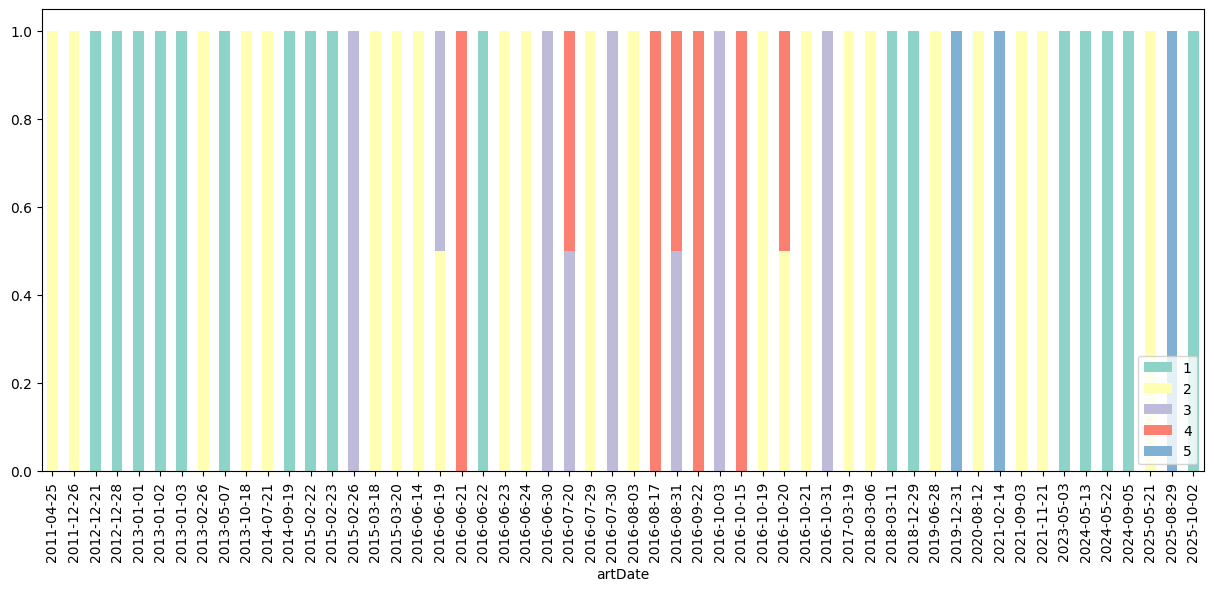

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
date_topic.plot.bar(ax=ax, stacked=True, color = plt.cm.Set3.colors)
ax.legend(loc='lower right')

### 6. 主題模型分析結論

本章節整合了 LDA 與 GuidedLDA 的執行結果，對 PTT ETF 版的討論結構與演化進行了全方位的盤點，觀察到以下現象：

1. **核心討論熱點 (Core Discussion Focus)**：
   - **情緒與操作的交織**：透過主題模型的量化分佈可以發現，「市場情緒反應」與「特定標的操作（如 0050/006208）」始終是討論的核心。這顯示網友不僅是在討論金融產品本身，更多是在交流面對市場波動時的心理狀態與應對策略。
   - **特定議題的浮現**：透過 GuidedLDA 的引導，我們能更清晰地切分出「高股息」、「債券/利率」等次要主題，這些議題通常隨市場環境（如除息季或聯準會利率決策）而呈現週期性的熱度。

2. **主題演變與市場脈絡 (Evolutionary Trends)**：
   - **從單一到多元**：早期討論較多集中於基礎的成分股與費率比較，但隨著台灣 ETF 市場的成熟與全民化，近年來（特別是 2024 年後）討論內容變得更加破碎化且具高度情緒性，反映出參與群體廣泛化後所帶來的輿情特性。
   - **週期性與事件驅動**：主題的分佈隨時間呈現顯著的事件驅動特徵。透過時間序列的佔比圖，我們能精準捕捉到社群討論如何從單純的「市值型」標的，轉向追逐「高股息」或受宏觀經濟影響的「債券型」產品。

### 7. 專案總結與洞察

在本專案中，我們針對 PTT ETF 版的非結構化文本進行了完整的主題模型分析流程。以下是本次分析的詳細過程與結果解讀：

1.  **技術實作**：
    *   **環境適配與模型優化**：我們實作了基礎的 **LDA (Latent Dirichlet Allocation)** 與 **GuidedLDA**。透過 GuidedLDA，我們能夠利用預定義的主題關鍵詞（如「高股息」、「市值型」、「債券/利率」及「市場情緒」）來引導模型，產出更具業務解釋力的主題分類。
    *   **視覺化環境建構**：除了導入 `pyLDAvis`，我們解決了中文字體渲染問題，透過安裝 `fonts-noto-cjk` 並配置 Matplotlib，確保了分析圖表能達成專業級的成果展示。

2.  **視覺化結果**：
    *   **pyLDAvis 互動式分析**：透過主題泡泡圖與關鍵詞排行，揭示了每個主題的語義核心。在本資料集中，**市場情緒** 與 **市值型/操作** 佔據了最顯著的比例。
    *   **主題趨勢演變（時間序列分析）**：自 2024 年起，討論熱度隨市場波動劇增。模型量化結果顯示，討論熱點明顯向「特定標的操作」與「市場情緒宣洩」集中，這反映了台灣 ETF 市場全民化後的真實輿情現狀。

3.  **總結**：
    *   **社群關注重心**：透過模型量化分析證明，PTT 網友最關心的核心是「對市場波動的情緒反應」以及「0050 等指標性產品的具體操作」。
    *   **模型價值應用**：本流程展示了如何將社群輿情（非結構化文字）轉化為具備時間維度的量化洞察，為後續的投資情緒研究或金融產品開發奠定了基礎。